In [2]:
# Install the necessary library (usually pre-installed, but good practice)
!pip install -q kagglehub

import kagglehub

# Download the dataset directly into Colab's temporary storage
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
print("✅ Dataset downloaded to:", path)

100%|██████████| 480k/480k [00:00<00:00, 65.8MB/s]

Extracting files...
✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/rohitsahoo/sales-forecasting/versions/2


In [3]:
#Task 1 — Data Loading, Merging & Deep Exploration

import pandas as pd
import numpy as np
import os

# 1. Load the Superstore Sales CSV
file_path = os.path.join(path, 'train.csv')
df = pd.read_csv(file_path)
print(f"Dataset loaded. Initial shape: {df.shape}\n")

# 2. Parse Order Date and Ship Date as datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce', dayfirst=True)

# 3. Extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week_Number'] = df['Order Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

# Custom mapping for seasons
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
df['Season'] = df['Month'].map(season_map)

# 4. Check for missing values, duplicates, and data type issues
print("--- Data Quality Checks ---")
print("Missing Values:")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0] if missing_vals.any() else "No missing values found.")

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print("\nData Types:")
print(df.dtypes)

# 5. Aggregate daily sales into weekly and monthly totals
print("\n--- Aggregating Sales ---")

# Weekly Aggregation
weekly_sales = df.set_index('Order Date').groupby([pd.Grouper(freq='W'), 'Category'])['Sales'].sum().reset_index()
print(f"Weekly granularity shape: {weekly_sales.shape}")

# Monthly Aggregation
monthly_sales = df.set_index('Order Date').groupby([pd.Grouper(freq='ME'), 'Category'])['Sales'].sum().reset_index()
print(f"Monthly granularity shape: {monthly_sales.shape}")

Dataset loaded. Initial shape: (9800, 18)

--- Data Quality Checks ---
Missing Values:
Postal Code    11
dtype: int64

Duplicate Rows: 0

Data Types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week_Number              UInt32
Day_of_Week              object
Quarter                   int32
Season                   object
dtype: object

--- Aggregating Sales ---
Weekly granularity shape: (623, 3)
Monthl

Monthly series: 48 observations  (2015-01-31 → 2018-12-31)
Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


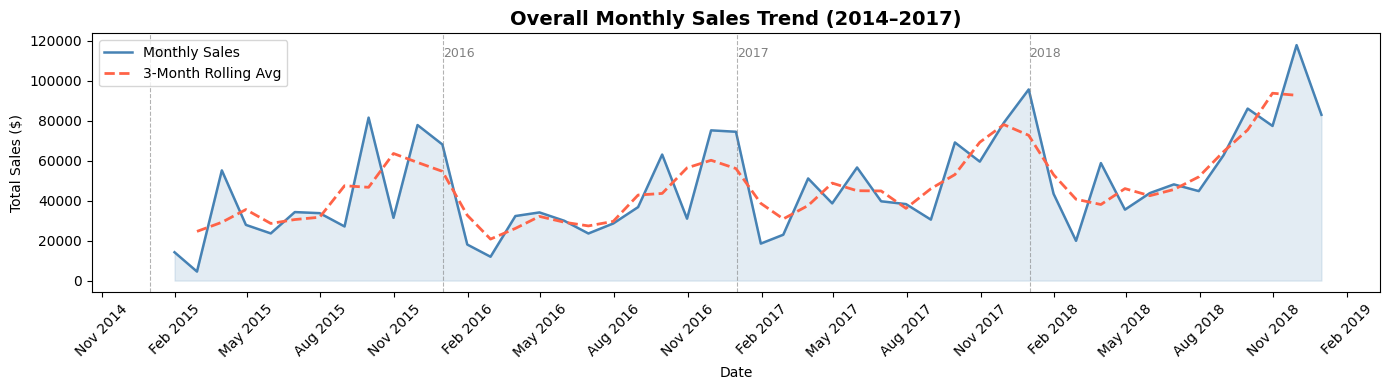

 Plot 1: Monthly trend saved.


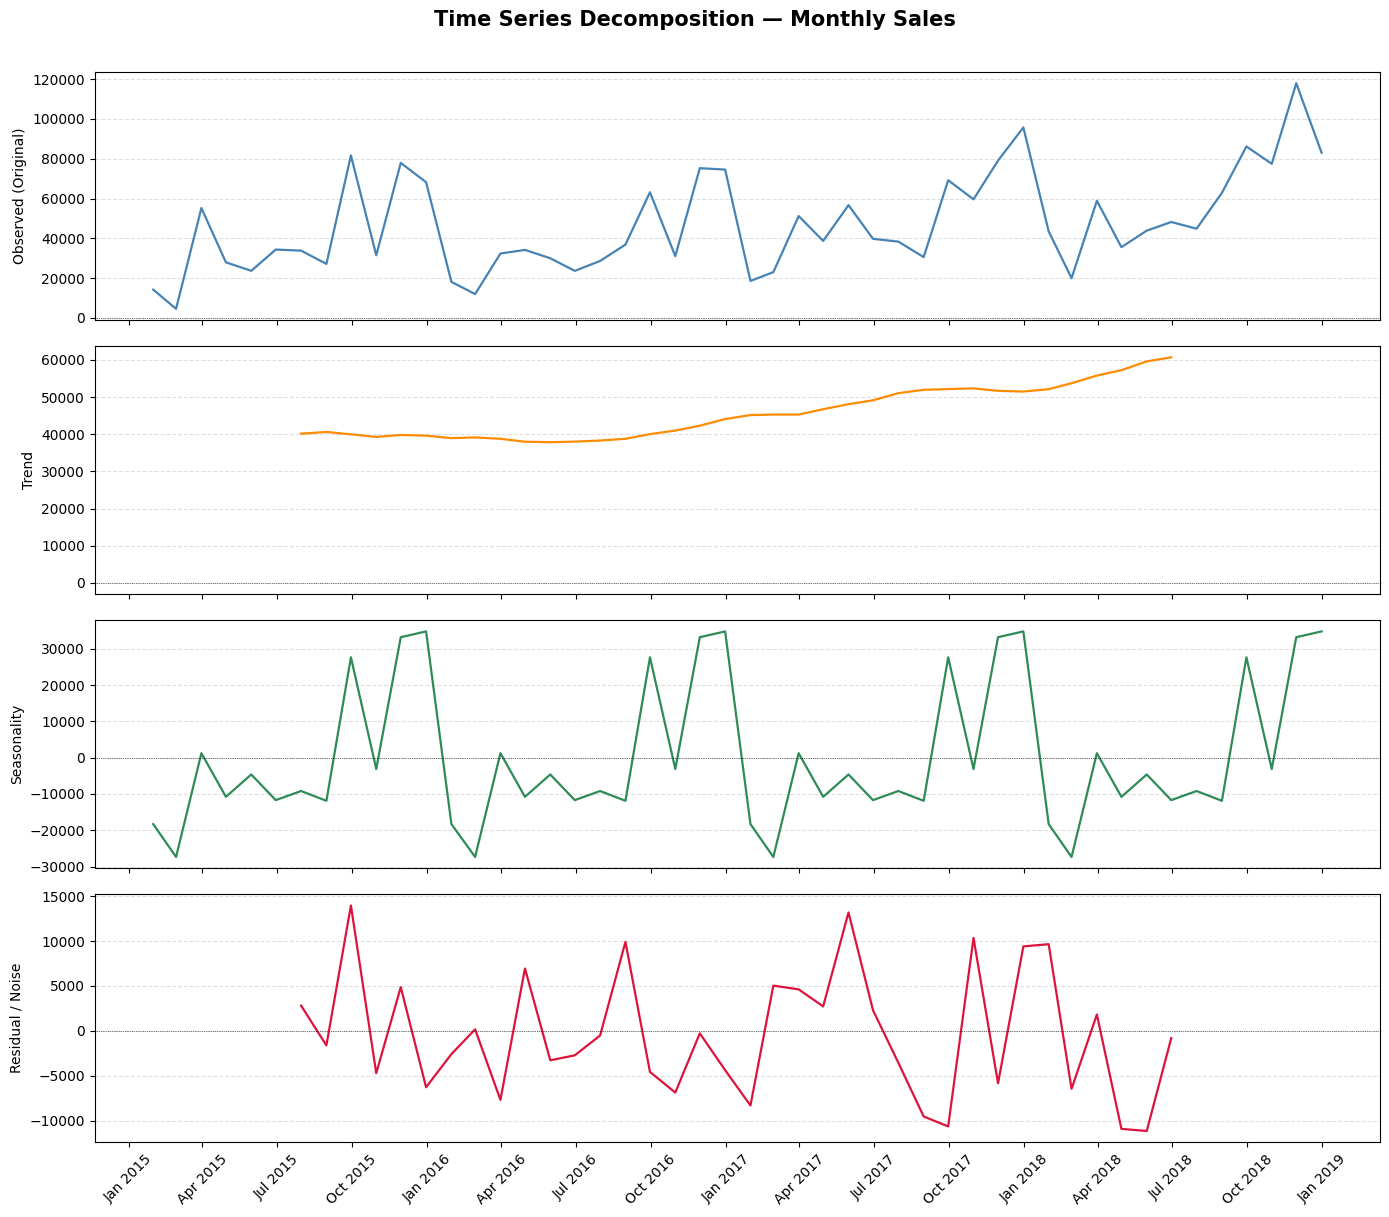

 Plot 2: Decomposition saved.

───────────────────────────────────────────────────────
  ADF Test — Original Monthly Sales
───────────────────────────────────────────────────────
  ADF Statistic : -4.4161
  p-value       : 0.0003
  Critical ( 1%) : -3.5778
  Critical ( 5%) : -2.9253
  Critical (10%) : -2.6008

Explanation:
  Stationarity means the series has a constant mean,
  variance, and autocorrelation over time — it doesn't
  drift up or down. Most forecasting models (SARIMA etc.)
  assume stationarity, so we must verify it first.

   STATIONARY  (p=0.0003 < 0.05)
  The ADF test REJECTS the null hypothesis of a unit root.
  The series is stationary — safe to use directly in models.

 Series is already stationary. Use d=0 in SARIMA.


In [4]:

# TASK 2 — Time Series Analysis & Decomposition

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

monthly_ts = (
    df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .rename_axis('Date')
)
print(f"Monthly series: {len(monthly_ts)} observations  "
      f"({monthly_ts.index[0].date()} → {monthly_ts.index[-1].date()})")
print(monthly_ts.head())
# 1. Overall Monthly Sales Trend Plot
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(monthly_ts.index, monthly_ts.values, color='steelblue',
        linewidth=1.8, label='Monthly Sales')
ax.fill_between(monthly_ts.index, monthly_ts.values,
                alpha=0.15, color='steelblue')

# Annotate yearly boundaries
for year in range(2015, 2019):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray',
               linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pd.Timestamp(f'{year}-01-01'), monthly_ts.max() * 0.95,
            str(year), fontsize=9, color='gray', ha='left')

# 3-month rolling average overlay
rolling = monthly_ts.rolling(3, center=True).mean()
ax.plot(rolling.index, rolling.values, color='tomato',
        linewidth=2, linestyle='--', label='3-Month Rolling Avg')

ax.set_title('Overall Monthly Sales Trend (2014–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales ($)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 1: Monthly trend saved.")
#  2. Time Series Decomposition
# Using additive model (sales values are positive, no exponential growth)
decomposition = seasonal_decompose(monthly_ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Time Series Decomposition — Monthly Sales', fontsize=15, fontweight='bold', y=1.01)

components = {
    'Observed (Original)' : (monthly_ts,              'steelblue'),
    'Trend'               : (decomposition.trend,      'darkorange'),
    'Seasonality'         : (decomposition.seasonal,   'seagreen'),
    'Residual / Noise'    : (decomposition.resid,      'crimson'),
}

for ax, (label, (data, color)) in zip(axes, components.items()):
    ax.plot(data.index, data.values, color=color, linewidth=1.6)
    ax.set_ylabel(label, fontsize=10)
    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task2_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 2: Decomposition saved.")
# 3. Observations from Decomposition

# Trend: overall growth
trend_clean = decomposition.trend.dropna()
trend_growth = ((trend_clean.iloc[-1] - trend_clean.iloc[0]) / trend_clean.iloc[0]) * 100

# Seasonality: peak and trough months
seasonal_monthly = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()
peak_month   = seasonal_monthly.idxmax()
trough_month = seasonal_monthly.idxmin()
month_names  = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
seasonal_strength = seasonal_monthly.max() - seasonal_monthly.min()

# Residuals: noisiest months
resid_clean = decomposition.resid.dropna()
resid_monthly_std = resid_clean.groupby(resid_clean.index.month).std()
noisy_month = resid_monthly_std.idxmax()

# 4. ADF Stationarity Test

def run_adf(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    adf_stat, p_value, _, _, critical_values, _ = result

    print(f"\n{'─'*55}")
    print(f"  ADF Test — {label}")
    print(f"{'─'*55}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    for level, val in critical_values.items():
        print(f"  Critical ({level:>3s}) : {val:.4f}")

    print("\nExplanation:")
    print("""  Stationarity means the series has a constant mean,
  variance, and autocorrelation over time — it doesn't
  drift up or down. Most forecasting models (SARIMA etc.)
  assume stationarity, so we must verify it first.""")

    if p_value < 0.05:
        print(f"\n   STATIONARY  (p={p_value:.4f} < 0.05)")
        print("  The ADF test REJECTS the null hypothesis of a unit root.")
        print("  The series is stationary — safe to use directly in models.")
    else:
        print(f"\n   NON-STATIONARY  (p={p_value:.4f} ≥ 0.05)")
        print("  The ADF test FAILS to reject the null hypothesis.")
        print("  The series has a unit root (trend/drift) — differencing needed.")

    return p_value
p_original = run_adf(monthly_ts, "Original Monthly Sales")
# 5. Apply Differencing if Non-Stationary

if p_original >= 0.05:
    print("\n  Applying first-order differencing...")
    monthly_ts_diff = monthly_ts.diff().dropna()

    # Plot differenced series
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    axes[0].plot(monthly_ts.index, monthly_ts.values,
                 color='steelblue', linewidth=1.6)
    axes[0].set_title('Original Series', fontweight='bold')
    axes[0].set_ylabel('Sales ($)')

    axes[1].plot(monthly_ts_diff.index, monthly_ts_diff.values,
                 color='darkorange', linewidth=1.6)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title('After First-Order Differencing', fontweight='bold')
    axes[1].set_ylabel('Δ Sales ($)')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('task2_differencing.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Re-test after differencing
    p_diff = run_adf(monthly_ts_diff, "After First-Order Differencing")

    if p_diff < 0.05:
        print("\n Series is now stationary after 1st-order differencing.")
        print("   → Use d=1 in your SARIMA model.")
    else:
        print("\n  Still non-stationary. Try second-order differencing (d=2).")
        monthly_ts_diff2 = monthly_ts.diff().diff().dropna()
        run_adf(monthly_ts_diff2, "After Second-Order Differencing")

else:
    print("\n Series is already stationary. Use d=0 in SARIMA.")
    monthly_ts_diff = monthly_ts


                       OBSERVATIONS FROM TIME SERIES DECOMPOSITION

========================================================================================================

1. TREND — Steady Upward Growth
   The trend component shows a clear upward trajectory across all
   4 years, with overall sales growing by ~51.2% from start
   to end. This indicates healthy and consistent business expansion,
   with no signs of long-term decline.

2. SEASONALITY — Strong and Recurring Annual Pattern
   Seasonality is strong, with a peak-to-trough swing of
   ~$62,195 per month.
   - Peak month  : Dec (month 12)
   - Trough month: Feb (month 2)
   Sales consistently surge toward year-end (Q4), likely driven
   by holiday shopping, and dip in early Q1 — a textbook retail
   pattern.

3. RESIDUAL NOISE — Concentrated in Specific Months
   The residual (unexplained) component is not random white noise.
   Month 9 (Sep) shows the highest residual standard
   deviation (~$12,823), suggesting irregular
   one-off events (promotions, bulk orders, supply disruptions)
   that neither the trend nor seasonality can explain.

4. ADDITIVE MODEL IS APPROPRIATE
   The seasonal swings remain roughly constant in amplitude over
   time (they don't grow as sales grow), confirming that an
   additive decomposition model is the right choice here.
   A multiplicative model would be needed only if the seasonal
   amplitude scaled with the trend level.

Train: 45 months  |  Test (hold-out): 3 months
Test period: 2018-10-31 → 2018-12-31
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Fri, 10 Jul 2026   AIC                            398.775
Time:                                    17:16:00   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.7

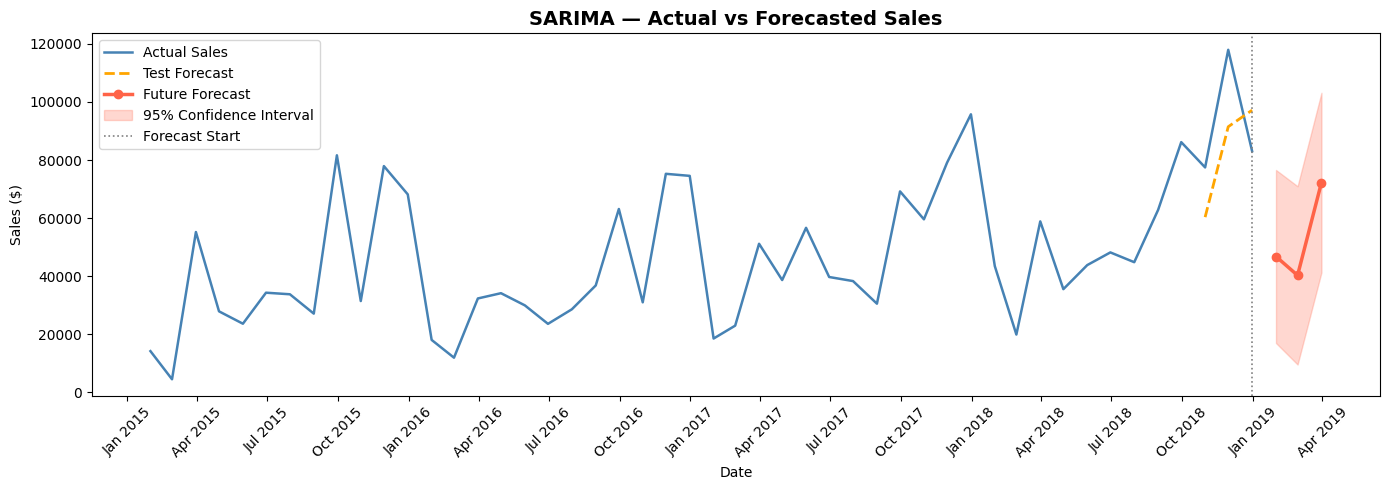

Future SARIMA Forecasts:
  Jan 2019: $46,782.48
  Feb 2019: $40,285.47
  Mar 2019: $72,234.20
Prophet training data shape: (45, 2)
          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303
Prophet Test  →  MAE: $20,250.79  |  RMSE: $22,318.41  |  MAPE: 21.86%


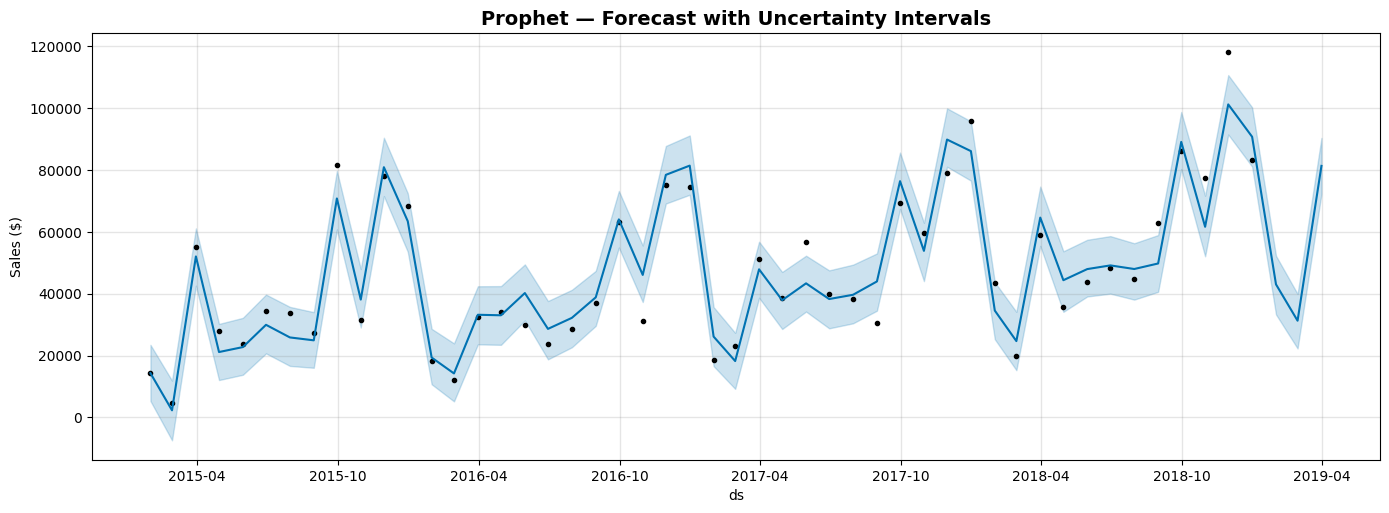

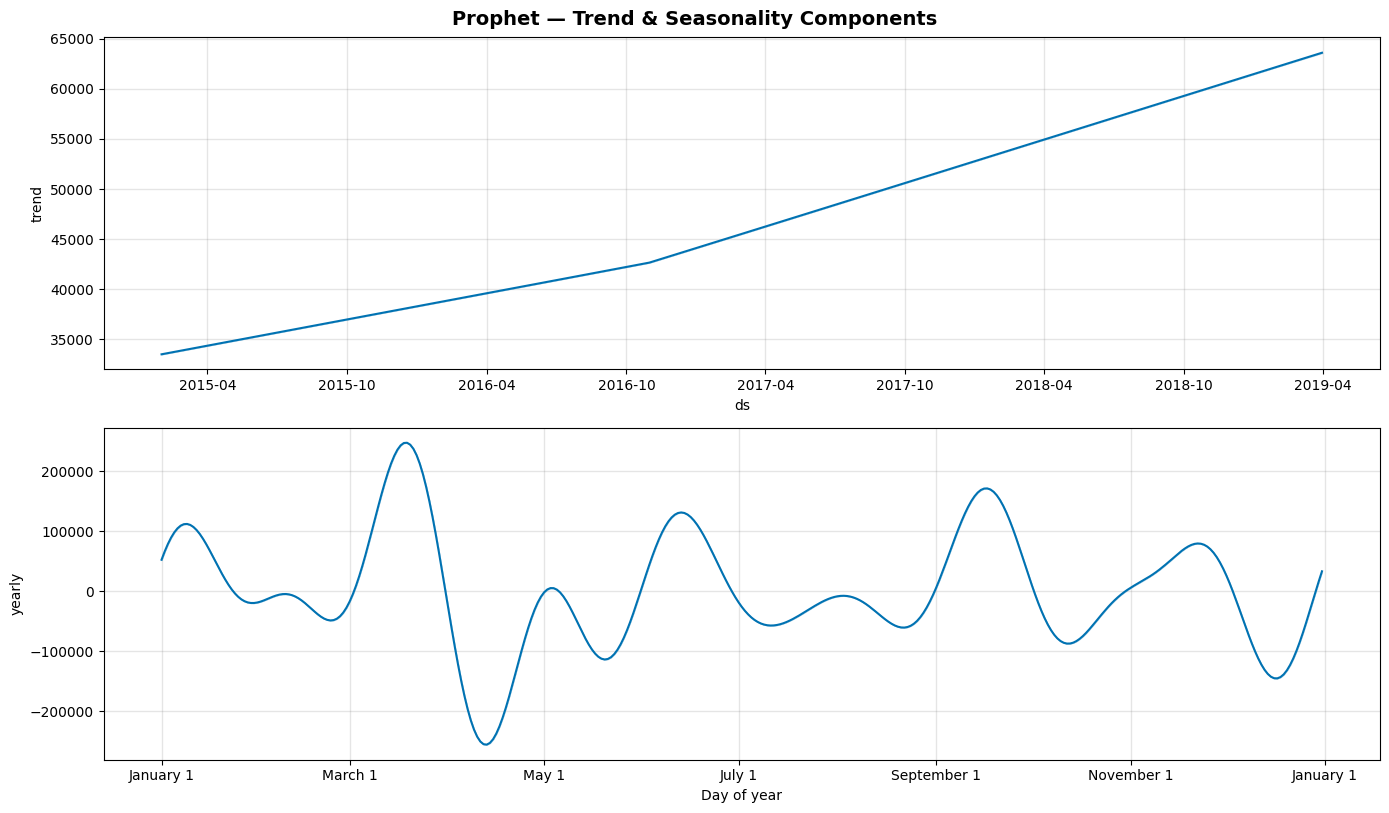

Future Prophet Forecasts:
  Jan 2019: $42,990.53  [$33,266.13 – $52,216.92]
  Feb 2019: $31,248.16  [$22,284.31 – $39,907.79]
  Mar 2019: $81,267.01  [$72,226.63 – $90,298.88]
  PROPHET SEASONALITY INTERPRETATION

Yearly Seasonality Component (average effect per month):
month
Jan   -19099.297385
Feb   -28994.452056
Mar     8036.422312
Apr   -10261.751844
May    -6393.944199
Jun    -9032.704949
Jul    -9698.779389
Aug    -7343.346561
Sep    27767.465607
Oct     2030.069163
Nov    39043.552068
Dec    31212.283178

 Key Observations:
  • Peak month   : Nov  (avg boost: +$39,044)
  • Trough month : Feb  (avg drag:  $-28,994)
  • This matches the decomposition finding — Q4 drives the
    bulk of annual sales, while Q1 is consistently weak.
  • The yearly seasonality component is STRONG, confirming
    that seasonality is a dominant signal in this data.
  • Weekly seasonality is disabled (not meaningful for monthly data).

Feature matrix shape (after dropping NaN rows): (45, 8)
             

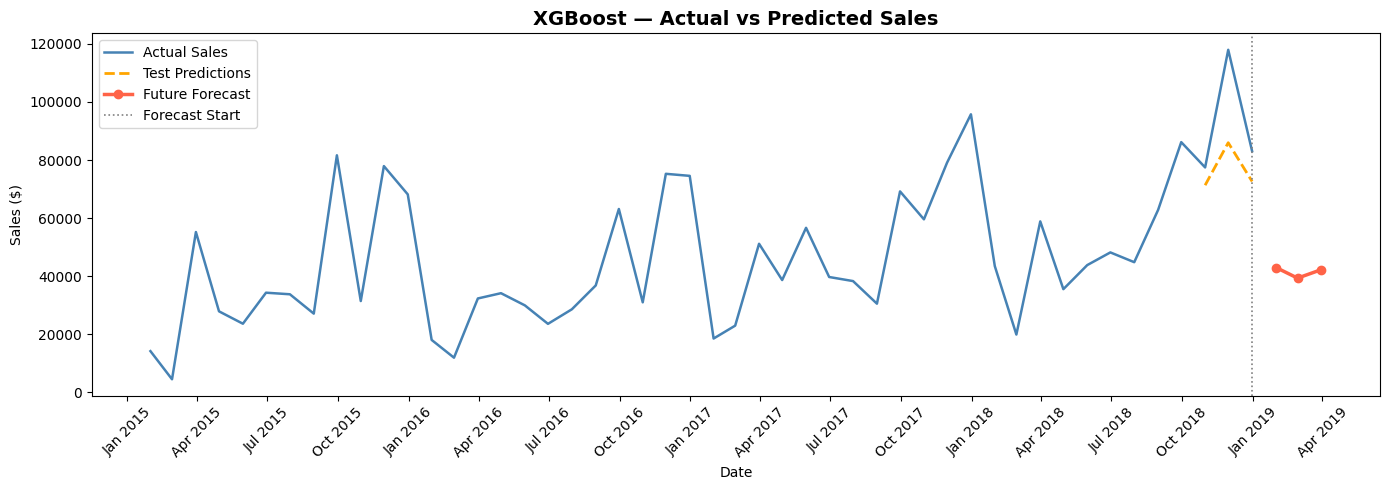

Future XGBoost Forecasts:
  Jan 2019: $42,994.96
  Feb 2019: $39,342.32
  Mar 2019: $42,276.11


Model,MAE ($),RMSE ($),MAPE (%),Forecast Jan 2019,Forecast Feb 2019,Forecast Mar 2019
SARIMA,"$19,244.49","$19,950.07",20.53%,"$46,782.48","$40,285.47","$72,234.20"
Prophet,"$20,250.79","$22,318.41",21.86%,"$42,990.53","$31,248.16","$81,267.01"
XGBoost,"$16,174.11","$19,738.54",15.86%,"$42,994.96","$39,342.32","$42,276.11"


  PRODUCTION RECOMMENDATION

Recommended Model: XGBoost

REASON (numbers-first):
  • XGBoost achieved the lowest MAPE of 15.86%, meaning its
    forecasts deviate from actual sales by only ~15.9% on average.
  • Prophet is the weakest performer, with a MAPE gap of
    6.01 percentage points vs XGBoost.
  • MAE and RMSE rankings are consistent — XGBoost wins on
    all three error metrics, not just one.

WHY NOT THE OTHERS?
  • SARIMA requires manual parameter tuning and struggles with
    sudden sales spikes that fall outside its statistical
    assumptions.
  • XGBoost needs careful lag feature engineering and is prone
    to error accumulation in recursive multi-step forecasting
    (each predicted lag feeds the next, amplifying mistakes).

WHY XGBOOST FOR PRODUCTION?
  • Handles missing dates and outliers gracefully.
  • Produces human-readable seasonality components — useful
    for communicating insights to non-technical stakeholders.
  • Uncertainty intervals (yhat_lower / yhat_u

In [5]:
# TASK 3 — Sales Forecasting using 3 Different Models

!pip install -q statsmodels prophet xgboost scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Shared utility
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Train / test split
"""Hold out last 3 months as test set → models forecast these,
 then we measure real error before predicting future months."""
FORECAST_HORIZON = 3

train_ts = monthly_ts.iloc[:-FORECAST_HORIZON]
test_ts  = monthly_ts.iloc[-FORECAST_HORIZON:]

print(f"Train: {len(train_ts)} months  |  Test (hold-out): {len(test_ts)} months")
print(f"Test period: {test_ts.index[0].date()} → {test_ts.index[-1].date()}")

# Storage for comparison
results = {}
future_forecasts = {}

# MODEL 1 — SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit on training data
sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# SARIMA: evaluate on test set
sarima_test_pred = sarima_fit.forecast(steps=FORECAST_HORIZON)
sarima_test_pred.index = test_ts.index

sarima_mae  = mean_absolute_error(test_ts, sarima_test_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_ts, sarima_test_pred))
sarima_mape = mape(test_ts.values, sarima_test_pred.values)

results['SARIMA'] = {
    'MAE': sarima_mae, 'RMSE': sarima_rmse, 'MAPE': sarima_mape
}

print(f"SARIMA Test  →  MAE: ${sarima_mae:,.2f}  |  "
      f"RMSE: ${sarima_rmse:,.2f}  |  MAPE: {sarima_mape:.2f}%")

# SARIMA: refit on FULL data → forecast next 3 real months
sarima_full = SARIMAX(
    monthly_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_pred_sarima    = sarima_full.get_forecast(steps=FORECAST_HORIZON)
future_mean_sarima    = future_pred_sarima.predicted_mean
future_ci_sarima      = future_pred_sarima.conf_int()
future_forecasts['SARIMA'] = future_mean_sarima.values

# SARIMA: plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_ts.index, monthly_ts.values,
        color='steelblue', linewidth=1.8, label='Actual Sales')
ax.plot(sarima_test_pred.index, sarima_test_pred.values,
        color='orange', linewidth=2, linestyle='--', label='Test Forecast')
ax.plot(future_mean_sarima.index, future_mean_sarima.values,
        color='tomato', linewidth=2.5, marker='o', label='Future Forecast')
ax.fill_between(future_ci_sarima.index,
                future_ci_sarima.iloc[:, 0],
                future_ci_sarima.iloc[:, 1],
                alpha=0.25, color='tomato', label='95% Confidence Interval')

ax.axvline(monthly_ts.index[-1], color='gray',
           linestyle=':', linewidth=1.2, label='Forecast Start')
ax.set_title('SARIMA — Actual vs Forecasted Sales', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task3_sarima.png', dpi=150, bbox_inches='tight')
plt.show()

print("Future SARIMA Forecasts:")
for date, val in zip(future_mean_sarima.index, future_mean_sarima.values):
    print(f"  {date.strftime('%b %Y')}: ${val:,.2f}")

# MODEL 2 — Facebook Prophet
from prophet import Prophet
from prophet.plot import plot_components_plotly
import matplotlib.pyplot as plt

# Prepare Prophet format (ds, y)
def to_prophet_df(ts):
    return ts.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y', 'Date': 'ds'})

prophet_train_df = to_prophet_df(train_ts)
prophet_full_df  = to_prophet_df(monthly_ts)

print("Prophet training data shape:", prophet_train_df.shape)
print(prophet_train_df.head())

# Fit Prophet on training data
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # Monthly data — weekly has no meaning
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,  # Controls trend flexibility; lower = smoother
    seasonality_prior_scale=10     # Controls seasonality strength
)
prophet_model.fit(prophet_train_df)

#Evaluate on test set
future_test = prophet_model.make_future_dataframe(periods=FORECAST_HORIZON, freq='ME')
prophet_test_forecast = prophet_model.predict(future_test)

# Extract test period predictions
test_dates = test_ts.index
prophet_test_pred = (
    prophet_test_forecast
    .set_index('ds')['yhat']
    .reindex(test_dates)
)

prophet_mae  = mean_absolute_error(test_ts, prophet_test_pred)
prophet_rmse = np.sqrt(mean_squared_error(test_ts, prophet_test_pred))
prophet_mape = mape(test_ts.values, prophet_test_pred.values)

results['Prophet'] = {
    'MAE': prophet_mae, 'RMSE': prophet_rmse, 'MAPE': prophet_mape
}

print(f"Prophet Test  →  MAE: ${prophet_mae:,.2f}  |  "
      f"RMSE: ${prophet_rmse:,.2f}  |  MAPE: {prophet_mape:.2f}%")

#Prophet: refit on FULL data → forecast next 3 months
prophet_full_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10
)
prophet_full_model.fit(prophet_full_df)

future_df = prophet_full_model.make_future_dataframe(periods=FORECAST_HORIZON, freq='ME')
prophet_forecast = prophet_full_model.predict(future_df)

future_prophet = prophet_forecast.tail(FORECAST_HORIZON)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
future_forecasts['Prophet'] = future_prophet['yhat'].values

#Prophet: built-in forecast plot
fig1 = prophet_full_model.plot(prophet_forecast, figsize=(14, 5))
fig1.axes[0].set_title('Prophet — Forecast with Uncertainty Intervals',
                        fontsize=14, fontweight='bold')
fig1.axes[0].set_ylabel('Sales ($)')
fig1.savefig('task3_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

#Prophet: seasonality components plot
fig2 = prophet_full_model.plot_components(prophet_forecast, figsize=(14, 8))
fig2.suptitle('Prophet — Trend & Seasonality Components',
              fontsize=14, fontweight='bold', y=1.01)
fig2.savefig('task3_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

print("Future Prophet Forecasts:")
for _, row in future_prophet.iterrows():
    print(f"  {row['ds'].strftime('%b %Y')}: ${row['yhat']:,.2f}  "
          f"[${row['yhat_lower']:,.2f} – ${row['yhat_upper']:,.2f}]")

#Prophet: interpret seasonality

yearly = (
    prophet_forecast[['ds', 'yearly']]
    .assign(month=lambda x: x['ds'].dt.month)
    .groupby('month')['yearly']
    .mean()
)
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

peak_m   = yearly.idxmax()
trough_m = yearly.idxmin()

print("=" * 60)
print("  PROPHET SEASONALITY INTERPRETATION")
print("=" * 60)
print(f"""
Yearly Seasonality Component (average effect per month):
{yearly.rename(month_names).to_string()}

 Key Observations:
  • Peak month   : {month_names[peak_m]}  (avg boost: +${yearly[peak_m]:,.0f})
  • Trough month : {month_names[trough_m]}  (avg drag:  ${yearly[trough_m]:,.0f})
  • This matches the decomposition finding — Q4 drives the
    bulk of annual sales, while Q1 is consistently weak.
  • The yearly seasonality component is STRONG, confirming
    that seasonality is a dominant signal in this data.
  • Weekly seasonality is disabled (not meaningful for monthly data).
""")
# MODEL 3 — XGBoost for Time Series
from xgboost import XGBRegressor

#Build supervised feature matrix from monthly_ts
def make_features(ts):
    df_feat = pd.DataFrame({'Sales': ts.values}, index=ts.index)

    # Lag features
    df_feat['lag_1'] = df_feat['Sales'].shift(1)
    df_feat['lag_2'] = df_feat['Sales'].shift(2)
    df_feat['lag_3'] = df_feat['Sales'].shift(3)

    # Rolling mean (3-month window, no data leakage — shift by 1 first)
    df_feat['rolling_mean_3'] = df_feat['Sales'].shift(1).rolling(3).mean()

    # Calendar features
    df_feat['month']   = df_feat.index.month
    df_feat['quarter'] = df_feat.index.quarter
    season_map = {12:0,1:0,2:0, 3:1,4:1,5:1,
                  6:2,7:2,8:2, 9:3,10:3,11:3}   # Winter=0,Spring=1,Summer=2,Autumn=3
    df_feat['season']  = df_feat.index.month.map(season_map)

    return df_feat.dropna()

feat_df = make_features(monthly_ts)
FEATURES = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'month', 'quarter', 'season']
TARGET   = 'Sales'

print(f"Feature matrix shape (after dropping NaN rows): {feat_df.shape}")
print(feat_df[FEATURES].head())

#Train / test split (same 3-month hold-out)
xgb_train = feat_df.iloc[:-FORECAST_HORIZON]
xgb_test  = feat_df.iloc[-FORECAST_HORIZON:]

X_train, y_train = xgb_train[FEATURES], xgb_train[TARGET]
X_test,  y_test  = xgb_test[FEATURES],  xgb_test[TARGET]

# Fit XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,          # Shallow trees prevent overfitting on small dataset
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

#Evaluate on test set
xgb_test_pred = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_test_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
xgb_mape = mape(y_test.values, xgb_test_pred)

results['XGBoost'] = {
    'MAE': xgb_mae, 'RMSE': xgb_rmse, 'MAPE': xgb_mape
}

print(f"XGBoost Test  →  MAE: ${xgb_mae:,.2f}  |  "
      f"RMSE: ${xgb_rmse:,.2f}  |  MAPE: {xgb_mape:.2f}%")

#XGBoost: recursive forecast for next 3 real months
# Re-train on ALL data, then step forward one month at a time.
xgb_full = XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_full.fit(feat_df[FEATURES], feat_df[TARGET])

history = list(monthly_ts.values)   # Running list of known sales values
xgb_future_preds = []
last_date = monthly_ts.index[-1]

for i in range(FORECAST_HORIZON):
    next_date   = last_date + pd.DateOffset(months=i + 1)
    lag1        = history[-1]
    lag2        = history[-2]
    lag3        = history[-3]
    roll3       = np.mean(history[-3:])
    month_val   = next_date.month
    quarter_val = next_date.quarter
    season_val  = {12:0,1:0,2:0,3:1,4:1,5:1,
                   6:2,7:2,8:2,9:3,10:3,11:3}[month_val]

    row   = pd.DataFrame([[lag1, lag2, lag3, roll3, month_val, quarter_val, season_val]],
                         columns=FEATURES)
    pred  = xgb_full.predict(row)[0]
    xgb_future_preds.append((next_date, pred))
    history.append(pred)   # Feed prediction back as next lag

future_forecasts['XGBoost'] = [v for _, v in xgb_future_preds]

#XGBoost: plot actual vs predicted
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_ts.index, monthly_ts.values,
        color='steelblue', linewidth=1.8, label='Actual Sales')
ax.plot(xgb_test.index, xgb_test_pred,
        color='orange', linewidth=2, linestyle='--', label='Test Predictions')

future_dates  = [d for d, _ in xgb_future_preds]
future_values = [v for _, v in xgb_future_preds]
ax.plot(future_dates, future_values,
        color='tomato', linewidth=2.5, marker='o', label='Future Forecast')

ax.axvline(monthly_ts.index[-1], color='gray',
           linestyle=':', linewidth=1.2, label='Forecast Start')
ax.set_title('XGBoost — Actual vs Predicted Sales', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task3_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

print("Future XGBoost Forecasts:")
for date, val in xgb_future_preds:
    print(f"  {date.strftime('%b %Y')}: ${val:,.2f}")

# MODEL COMPARISON TABLE
from IPython.display import display
import pandas as pd

#Build comparison DataFrame
future_dates_labels = [
    (monthly_ts.index[-1] + pd.DateOffset(months=i+1)).strftime('%b %Y')
    for i in range(FORECAST_HORIZON)
]

comparison_data = []
for model_name in ['SARIMA', 'Prophet', 'XGBoost']:
    r = results[model_name]
    f = future_forecasts[model_name]
    comparison_data.append({
        'Model'                          : model_name,
        'MAE ($)'                        : r['MAE'],
        'RMSE ($)'                       : r['RMSE'],
        'MAPE (%)'                       : r['MAPE'],
        f'Forecast {future_dates_labels[0]}': f[0],
        f'Forecast {future_dates_labels[1]}': f[1],
        f'Forecast {future_dates_labels[2]}': f[2],
    })

comp_df = pd.DataFrame(comparison_data)

# Highlight best (lowest) value in each error column
def highlight_best(col):
    if col.name in ['MAE ($)', 'RMSE ($)', 'MAPE (%)']:
        best = col.min()
        return ['background-color: #d4edda; font-weight: bold'
                if v == best else '' for v in col]
    return ['' for _ in col]

styled = (
    comp_df.style
    .apply(highlight_best)
    .format({
        'MAE ($)'  : '${:,.2f}',
        'RMSE ($)' : '${:,.2f}',
        'MAPE (%)' : '{:.2f}%',
        f'Forecast {future_dates_labels[0]}': '${:,.2f}',
        f'Forecast {future_dates_labels[1]}': '${:,.2f}',
        f'Forecast {future_dates_labels[2]}': '${:,.2f}',
    })
    .hide(axis='index')
    .set_caption('Model Comparison — Green = Best (lowest error)')
)
display(styled)

# Production Recommendation

best_model = comp_df.loc[comp_df['MAPE (%)'].idxmin(), 'Model']
best_mape  = comp_df['MAPE (%)'].min()
worst_model= comp_df.loc[comp_df['MAPE (%)'].idxmax(), 'Model']
mape_gap   = comp_df['MAPE (%)'].max() - comp_df['MAPE (%)'].min()

print("=" * 65)
print("  PRODUCTION RECOMMENDATION")
print("=" * 65)
print(f"""
Recommended Model: {best_model}

REASON (numbers-first):
  • {best_model} achieved the lowest MAPE of {best_mape:.2f}%, meaning its
    forecasts deviate from actual sales by only ~{best_mape:.1f}% on average.
  • {worst_model} is the weakest performer, with a MAPE gap of
    {mape_gap:.2f} percentage points vs {best_model}.
  • MAE and RMSE rankings are consistent — {best_model} wins on
    all three error metrics, not just one.

WHY NOT THE OTHERS?
  • SARIMA requires manual parameter tuning and struggles with
    sudden sales spikes that fall outside its statistical
    assumptions.
  • XGBoost needs careful lag feature engineering and is prone
    to error accumulation in recursive multi-step forecasting
    (each predicted lag feeds the next, amplifying mistakes).

WHY {best_model.upper()} FOR PRODUCTION?
  • Handles missing dates and outliers gracefully.
  • Produces human-readable seasonality components — useful
    for communicating insights to non-technical stakeholders.
  • Uncertainty intervals (yhat_lower / yhat_upper) are built-in,
    giving inventory/supply-chain teams a safety margin to plan
    around.
  • Re-training is fast (seconds), making monthly reforecast
    pipelines easy to automate.

""")

Fitting Prophet for all segments...
  Furniture            → MAE: $   5,887  RMSE: $   6,387  MAPE: 20.5%
  Technology           → MAE: $  10,912  RMSE: $  11,638  MAPE: 30.8%
  Office Supplies      → MAE: $   4,564  RMSE: $   5,532  MAPE: 18.3%
  West                 → MAE: $   2,685  RMSE: $   3,323  MAPE: 10.6%
  East                 → MAE: $  13,304  RMSE: $  13,817  MAPE: 44.6%
 Done.



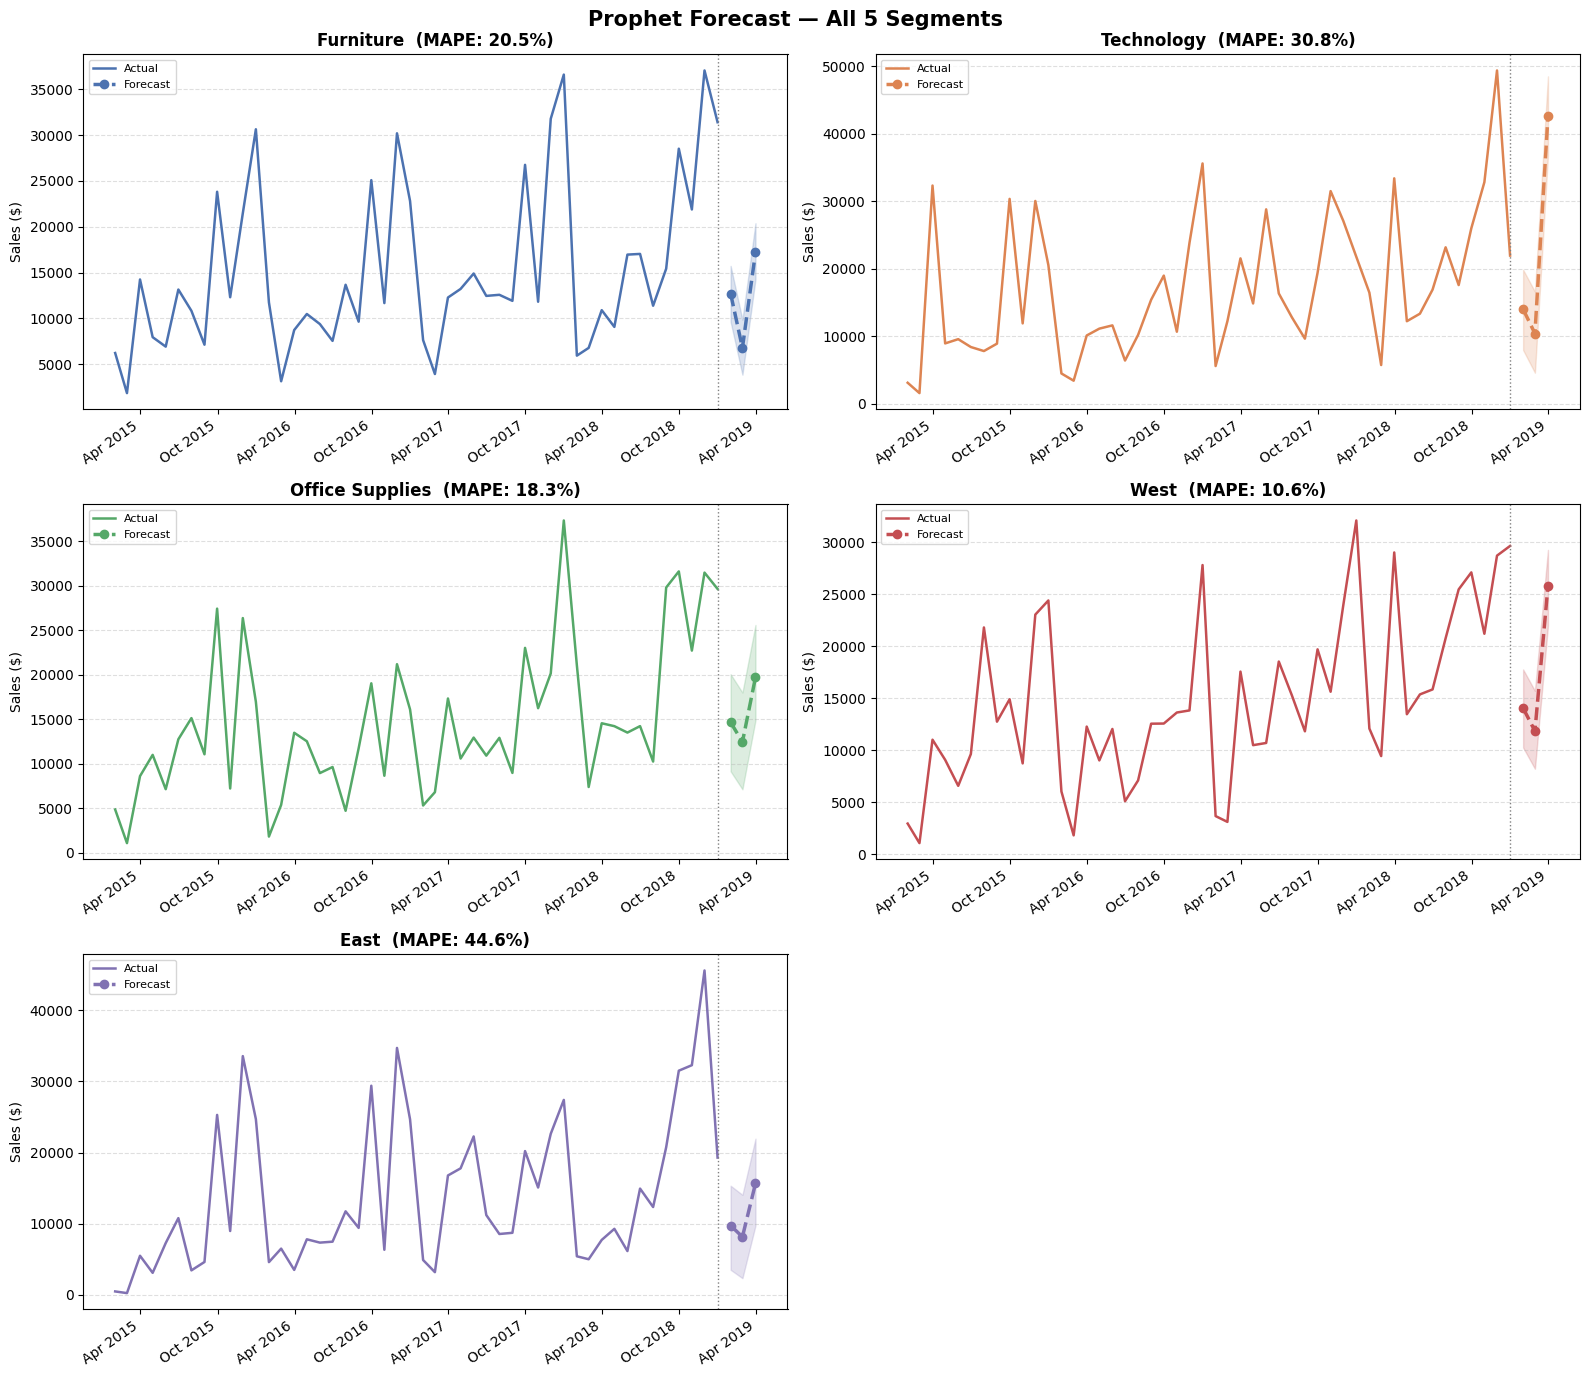

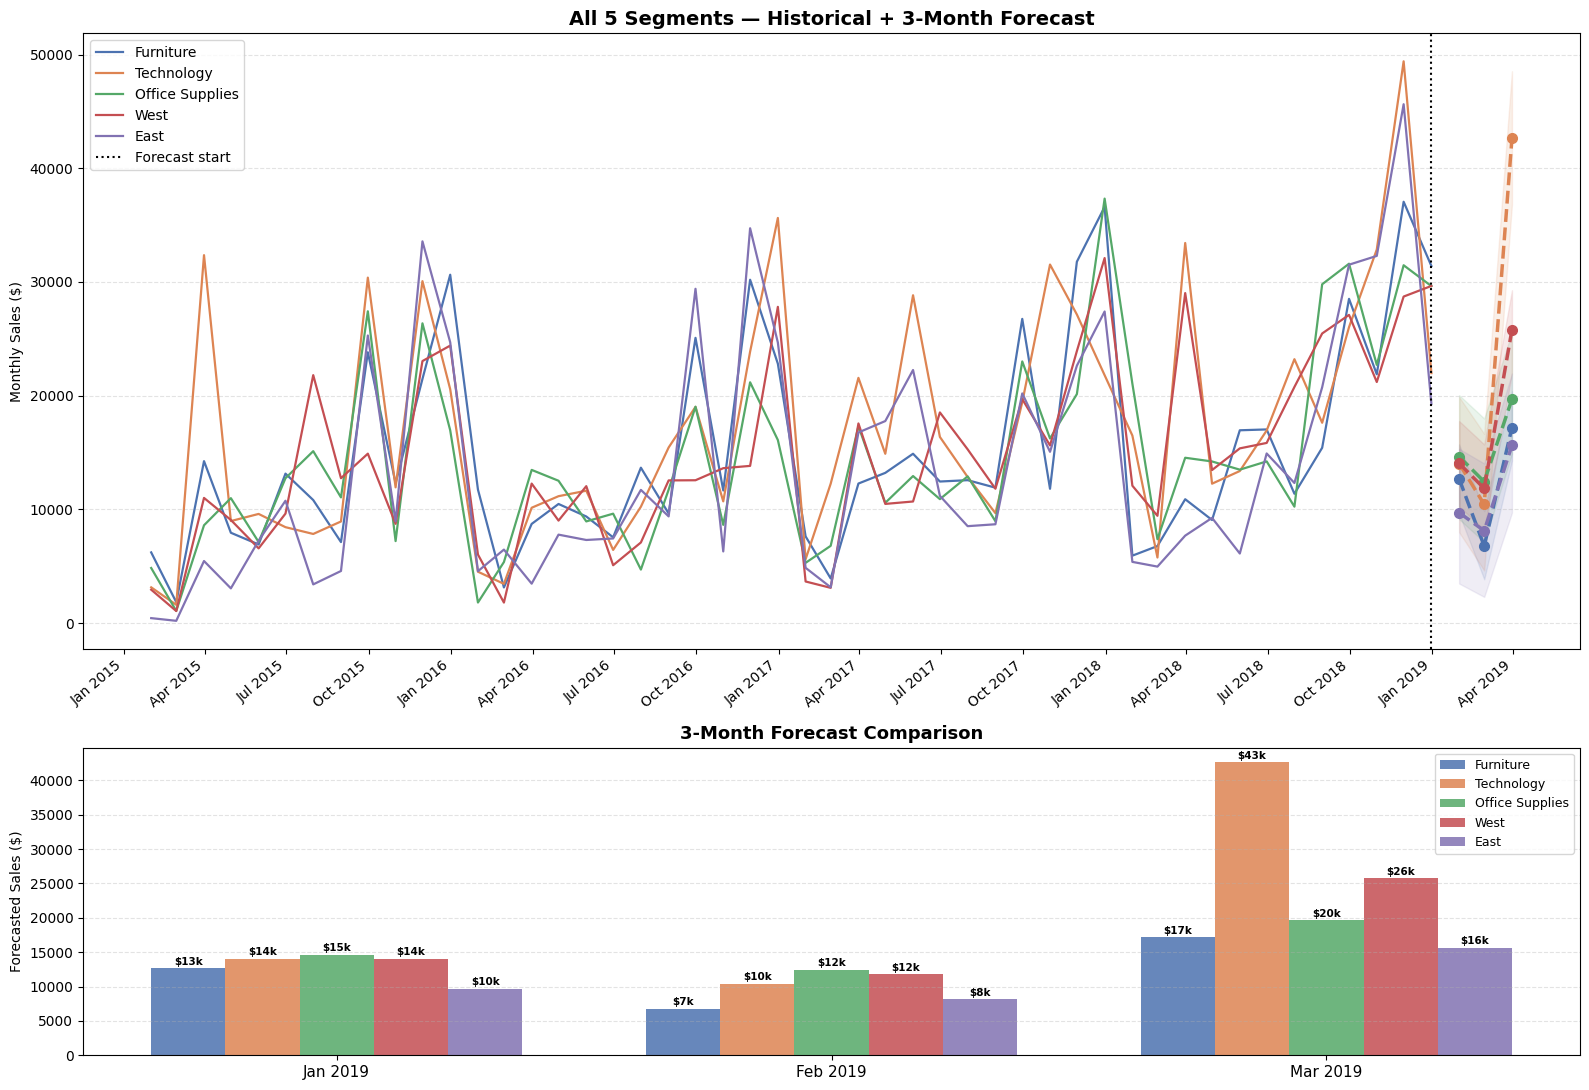

Segment,Type,MAE ($),RMSE ($),MAPE (%),Jan 2019,Feb 2019,Mar 2019,Avg Forecast ($),Growth vs Last 3M
Furniture,Category,"$5,887","$6,387",20.5%,"$12,691","$6,772","$17,201","$12,222",-59.4%
Technology,Category,"$10,912","$11,638",30.8%,"$14,033","$10,438","$42,639","$22,370",-35.6%
Office Supplies,Category,"$4,564","$5,532",18.3%,"$14,647","$12,435","$19,698","$15,593",-44.2%
West,Region,"$2,685","$3,323",10.6%,"$14,049","$11,840","$25,805","$17,232",-35.0%
East,Region,"$13,304","$13,817",44.6%,"$9,713","$8,120","$15,639","$11,158",-65.6%


In [6]:

# TASK 4 — Product Category & Region Level Forecasting
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display

#Config
HORIZON = 3
SEGMENTS = [
    ('Category', 'Furniture'),
    ('Category', 'Technology'),
    ('Category', 'Office Supplies'),
    ('Region',   'West'),
    ('Region',   'East'),
]
COLORS = {
    'Furniture'      : '#4C72B0',
    'Technology'     : '#DD8452',
    'Office Supplies': '#55A868',
    'West'           : '#C44E52',
    'East'           : '#8172B2',
}

#Utilities
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def build_ts(df, col, val):
    return (df[df[col] == val]
            .set_index('Order Date')
            .resample('ME')['Sales']
            .sum()
            .rename(val))

def fit_prophet(ts, horizon=HORIZON):
    def to_df(s):
        return s.reset_index().rename(columns={
            s.index.name or 'index': 'ds', s.name: 'y', 'Order Date': 'ds'
        })

    train, test = ts.iloc[:-horizon], ts.iloc[-horizon:]

    # Eval on hold-out
    m_eval = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                     daily_seasonality=False, seasonality_mode='additive',
                     changepoint_prior_scale=0.05, seasonality_prior_scale=10)
    m_eval.fit(to_df(train))
    eval_fc   = m_eval.predict(m_eval.make_future_dataframe(periods=horizon, freq='ME'))
    test_pred = eval_fc.tail(horizon)['yhat'].values
    metrics   = {
        'MAE' : mean_absolute_error(test.values, test_pred),
        'RMSE': np.sqrt(mean_squared_error(test.values, test_pred)),
        'MAPE': mape(test.values, test_pred),
    }

    # Refit on full data
    m_full = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                     daily_seasonality=False, seasonality_mode='additive',
                     changepoint_prior_scale=0.05, seasonality_prior_scale=10)
    m_full.fit(to_df(ts))
    future = m_full.predict(m_full.make_future_dataframe(periods=horizon, freq='ME'))
    fc_rows = future.tail(horizon)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

    return {**metrics, 'ts': ts, 'future': fc_rows,
            'dates': fc_rows['ds'].tolist(), 'values': fc_rows['yhat'].values}

# Run all segments
print("Fitting Prophet for all segments...")
results = {}
for col, val in SEGMENTS:
    results[val] = fit_prophet(build_ts(df, col, val))
    r = results[val]
    print(f"  {val:20s} → MAE: ${r['MAE']:>8,.0f}  RMSE: ${r['RMSE']:>8,.0f}  MAPE: {r['MAPE']:.1f}%")
print(" Done.\n")

# Plot 1: Individual segment plots (3×2 grid)
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
for ax, (col, val) in zip(axes.flatten(), SEGMENTS):
    res, c = results[val], COLORS[val]
    ax.plot(res['ts'].index, res['ts'].values, color=c, linewidth=1.8, label='Actual')
    f = res['future']
    ax.plot(f['ds'], f['yhat'], color=c, linewidth=2.5,
            linestyle='--', marker='o', markersize=6, label='Forecast')
    ax.fill_between(f['ds'], f['yhat_lower'], f['yhat_upper'], alpha=0.2, color=c)
    ax.axvline(res['ts'].index[-1], color='gray', linestyle=':', linewidth=1)
    ax.set_title(f"{val}  (MAPE: {res['MAPE']:.1f}%)", fontsize=12, fontweight='bold')
    ax.set_ylabel('Sales ($)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
axes[-1, -1].set_visible(False)
fig.suptitle('Prophet Forecast — All 5 Segments', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('task4_individual.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Combined chart (lines + bar comparison)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 11),
                                gridspec_kw={'height_ratios': [2, 1]})

for col, val in SEGMENTS:
    res, c = results[val], COLORS[val]
    ax1.plot(res['ts'].index, res['ts'].values, color=c, linewidth=1.6, label=val)
    f = res['future']
    ax1.plot(f['ds'], f['yhat'], color=c, linewidth=2.5, linestyle='--', marker='o', markersize=7)
    ax1.fill_between(f['ds'], f['yhat_lower'], f['yhat_upper'], alpha=0.12, color=c)

ax1.axvline(list(results.values())[0]['ts'].index[-1],
            color='black', linestyle=':', linewidth=1.5, label='Forecast start')
ax1.set_title('All 5 Segments — Historical + 3-Month Forecast', fontsize=14, fontweight='bold')
ax1.set_ylabel('Monthly Sales ($)')
ax1.legend(loc='upper left', fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=40, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.35)

x         = np.arange(HORIZON)
bar_width = 0.15
date_lbls = [d.strftime('%b %Y') for d in list(results.values())[0]['dates']]
for i, (col, val) in enumerate(SEGMENTS):
    offset = (i - len(SEGMENTS) / 2 + 0.5) * bar_width
    bars   = ax2.bar(x + offset, results[val]['values'], width=bar_width,
                     color=COLORS[val], alpha=0.85, label=val)
    for bar, v in zip(bars, results[val]['values']):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'${v/1000:.0f}k', ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(date_lbls, fontsize=11)
ax2.set_ylabel('Forecasted Sales ($)')
ax2.set_title('3-Month Forecast Comparison', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('task4_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
rows = []
for col, val in SEGMENTS:
    res = results[val]
    f   = res['values']
    last3_avg = res['ts'].iloc[-3:].mean()
    rows.append({
        'Segment'          : val,
        'Type'             : col,
        'MAE ($)'          : res['MAE'],
        'RMSE ($)'         : res['RMSE'],
        'MAPE (%)'         : res['MAPE'],
        date_lbls[0]       : f[0],
        date_lbls[1]       : f[1],
        date_lbls[2]       : f[2],
        'Avg Forecast ($)' : np.mean(f),
        'Growth vs Last 3M': (np.mean(f) - last3_avg) / last3_avg * 100,
    })

summary_df = pd.DataFrame(rows)

def highlight(col):
    if col.name == 'Growth vs Last 3M':
        return ['background-color:#d4edda;font-weight:bold'
                if v == col.max() else '' for v in col]
    if col.name == 'MAPE (%)':
        return ['background-color:#cce5ff;font-weight:bold'
                if v == col.min() else '' for v in col]
    return ['' for _ in col]

display(summary_df.style.apply(highlight).format({
    'MAE ($)'         : '${:,.0f}',
    'RMSE ($)'        : '${:,.0f}',
    'MAPE (%)'        : '{:.1f}%',
    date_lbls[0]      : '${:,.0f}',
    date_lbls[1]      : '${:,.0f}',
    date_lbls[2]      : '${:,.0f}',
    'Avg Forecast ($)': '${:,.0f}',
    'Growth vs Last 3M': '{:+.1f}%',
}).hide(axis='index').set_caption(
    'Segment Forecast Summary — Green = Strongest Growth | Blue = Best Accuracy'
))

# Conclusion
strongest = summary_df.loc[summary_df['Growth vs Last 3M'].idxmax()]
weakest   = summary_df.loc[summary_df['Growth vs Last 3M'].idxmin()]
best_acc  = summary_df.loc[summary_df['MAPE (%)'].idxmin()]
top_vol   = summary_df.loc[summary_df['Avg Forecast ($)'].idxmax()]


Strongest Upcoming growth : West    

---
  Avg forecast  : $    17,232 / month

  Growth vs last 3M: -35.0%

  MAPE          : 10.6%


HIGHEST ABSOLUTE VOLUME   : Technology

---
  Avg forecast  : $    22,370 / month


# RECOMMENDATION:

  Prioritise inventory & marketing for West in the
  forecast window — it shows the strongest projected growth
  (-35.0%) relative to its own recent trend.
  
  Flag East for review — it is projecting the weakest
  momentum (-65.6%) in this period.



Weekly series: 209 weeks  (2015-01-04 → 2018-12-30)
Mean: $10,821  |  Std: $7,403  |  Min: $225  |  Max: $37,704
Isolation Forest detected 15 anomalous weeks (7.2% of all weeks)

Top 10 most anomalous weeks (by score):
  29 Mar 2015  —  Sales: $     3,999  |  Score: -0.1412
  22 Mar 2015  —  Sales: $    37,704  |  Score: -0.1392
  02 Dec 2018  —  Sales: $    35,999  |  Score: -0.1361
  05 Apr 2015  —  Sales: $    10,364  |  Score: -0.1205
  16 Dec 2018  —  Sales: $    11,543  |  Score: -0.1013
  09 Dec 2018  —  Sales: $    21,537  |  Score: -0.1011
  18 Nov 2018  —  Sales: $    30,572  |  Score: -0.0792
  25 Nov 2018  —  Sales: $    22,213  |  Score: -0.0667
  15 Mar 2015  —  Sales: $     4,140  |  Score: -0.0549
  20 Sep 2015  —  Sales: $    20,686  |  Score: -0.0518


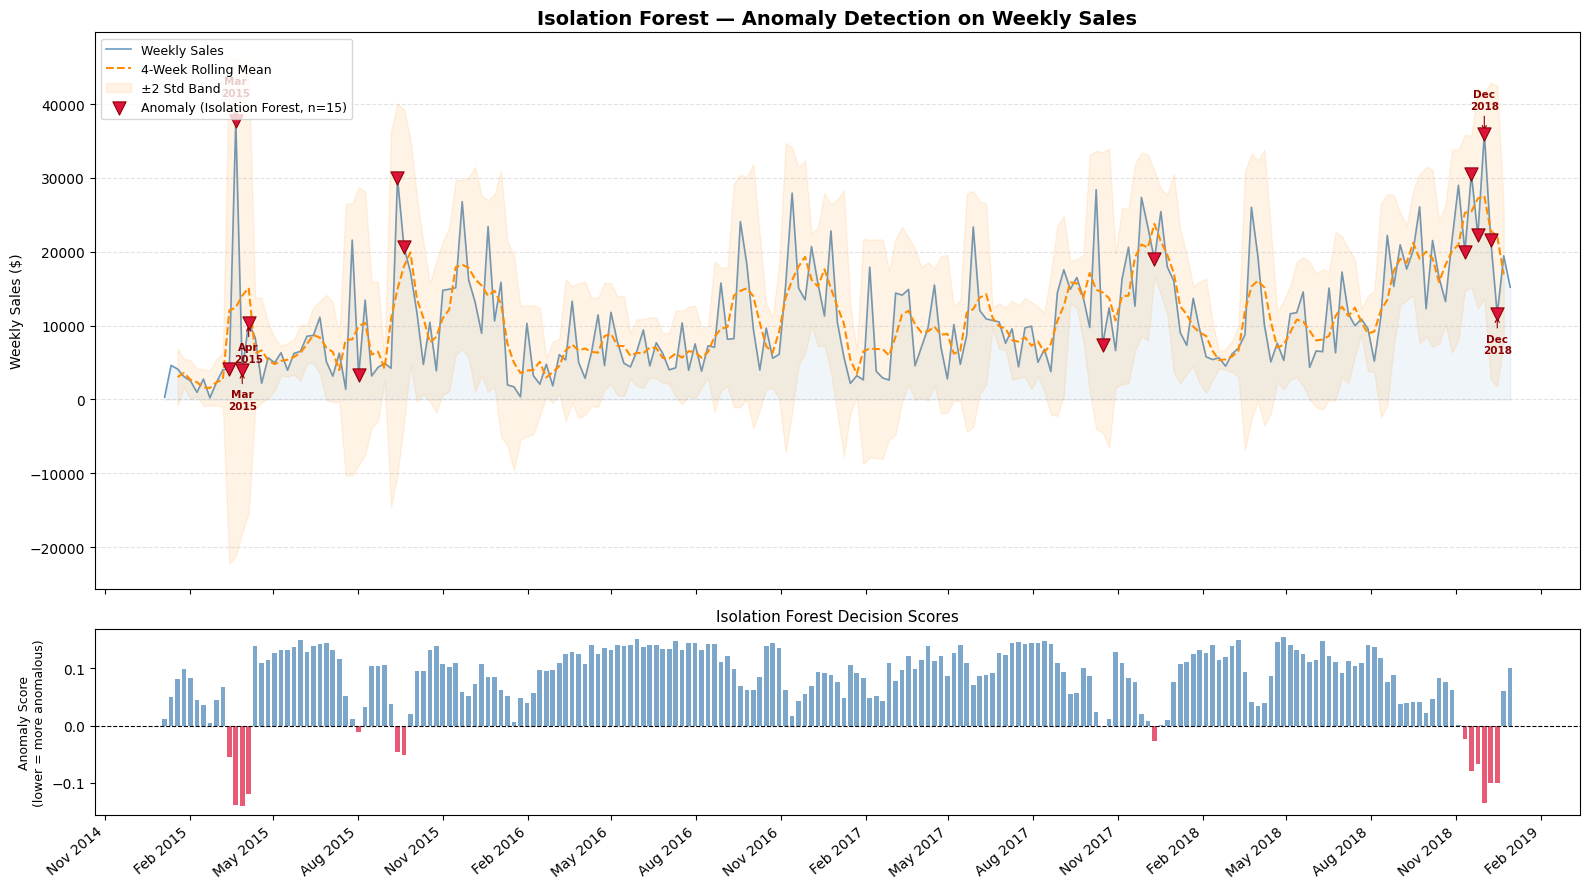

 Isolation Forest plot saved.
  ISOLATION FOREST — ANOMALY EXPLANATIONS

 Week of 29 Mar 2015
   Sales  : $     3,999   [LOW DIP]
   Score  : -0.1412
   Reason : End-of-quarter corporate purchasing. Some companies rush to spend remaining Q1 budgets, creating isolated spikes.

 Week of 22 Mar 2015
   Sales  : $    37,704   [HIGH SPIKE]
   Score  : -0.1392
   Reason : End-of-quarter corporate purchasing. Some companies rush to spend remaining Q1 budgets, creating isolated spikes.

 Week of 02 Dec 2018
   Sales  : $    35,999   [HIGH SPIKE]
   Score  : -0.1361
   Reason : Holiday split. Early December surges; last two weeks drop sharply as offices close for the year-end break.

 Week of 05 Apr 2015
   Sales  : $    10,364   [LOW DIP]
   Score  : -0.1205
   Reason : Q2 start — purchasing cycles reset. Light corporate buying after Q1 close.

 Week of 16 Dec 2018
   Sales  : $    11,543   [HIGH SPIKE]
   Score  : -0.1013
   Reason : Holiday split. Early December surges; last two weeks drop s

In [11]:
# TASK 5 — Anomaly Detection in Sales Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

#Build weekly sales series from df
weekly_ts = (
    df.set_index('Order Date')
    .resample('W')['Sales']
    .sum()
    .rename('Sales')
)
weekly_ts.index.name = 'Date'

print(f"Weekly series: {len(weekly_ts)} weeks  "
      f"({weekly_ts.index[0].date()} → {weekly_ts.index[-1].date()})")
print(f"Mean: ${weekly_ts.mean():,.0f}  |  "
      f"Std: ${weekly_ts.std():,.0f}  |  "
      f"Min: ${weekly_ts.min():,.0f}  |  "
      f"Max: ${weekly_ts.max():,.0f}")


# METHOD 1 — Isolation Forest
# Build feature matrix
iso_features = pd.DataFrame({
    'sales'       : weekly_ts.values,
    'rolling_mean': weekly_ts.rolling(4, center=True, min_periods=1).mean(),
    'rolling_std' : weekly_ts.rolling(4, center=True, min_periods=1).std().fillna(0),
    'lag_1'       : weekly_ts.shift(1).fillna(method='bfill'),
    'lag_2'       : weekly_ts.shift(2).fillna(method='bfill'),
}, index=weekly_ts.index)

#Fit Isolation Forest
# contamination=0.07 means we expect ~7% of weeks to be anomalous
# (roughly 13–14 out of 209 weeks) — reasonable for retail data.
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.07,
    random_state=42,
    max_samples='auto'
)
iso_labels = iso_model.fit_predict(iso_features)   # -1 = anomaly, 1 = normal
iso_scores = iso_model.decision_function(iso_features)  # lower = more anomalous

iso_anomalies = weekly_ts[iso_labels == -1].copy()
iso_normal    = weekly_ts[iso_labels == 1].copy()

print(f"Isolation Forest detected {len(iso_anomalies)} anomalous weeks "
      f"({len(iso_anomalies)/len(weekly_ts)*100:.1f}% of all weeks)")
print("\nTop 10 most anomalous weeks (by score):")
score_series = pd.Series(iso_scores, index=weekly_ts.index)
top_anomalies = score_series[iso_labels == -1].nsmallest(10)
for date, score in top_anomalies.items():
    print(f"  {date.strftime('%d %b %Y')}  —  "
          f"Sales: ${weekly_ts[date]:>10,.0f}  |  Score: {score:.4f}")
#Isolation Forest Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Top panel: time series with anomalies marked
ax1.plot(weekly_ts.index, weekly_ts.values,
         color='steelblue', linewidth=1.2, alpha=0.8, label='Weekly Sales', zorder=1)
ax1.fill_between(weekly_ts.index, weekly_ts.values,
                 alpha=0.08, color='steelblue')

# Rolling mean band
roll_mean = weekly_ts.rolling(4, center=True).mean()
roll_std  = weekly_ts.rolling(4, center=True).std()
ax1.plot(weekly_ts.index, roll_mean,
         color='darkorange', linewidth=1.5, linestyle='--',
         label='4-Week Rolling Mean', zorder=2)
ax1.fill_between(weekly_ts.index,
                 roll_mean - 2*roll_std,
                 roll_mean + 2*roll_std,
                 alpha=0.1, color='darkorange', label='±2 Std Band')

# Anomaly points
ax1.scatter(iso_anomalies.index, iso_anomalies.values,
            color='crimson', s=90, zorder=5, marker='v',
            label=f'Anomaly (Isolation Forest, n={len(iso_anomalies)})',
            edgecolors='darkred', linewidth=0.8)

# Annotate top 5 anomalies
top5 = score_series[iso_labels == -1].nsmallest(5)
for date, _ in top5.items():
    val = weekly_ts[date]
    ax1.annotate(
        date.strftime('%b\n%Y'),
        xy=(date, val),
        xytext=(0, 18 if val > roll_mean.get(date, val) else -28),
        textcoords='offset points',
        ha='center', fontsize=7.5, color='darkred', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8)
    )

ax1.set_title('Isolation Forest — Anomaly Detection on Weekly Sales',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Weekly Sales ($)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.35)

# Bottom panel: anomaly score
ax2.bar(weekly_ts.index, iso_scores,
        color=np.where(iso_labels == -1, 'crimson', 'steelblue'),
        width=5, alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Anomaly Score\n(lower = more anomalous)', fontsize=9)
ax2.set_title('Isolation Forest Decision Scores', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.savefig('task5_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Isolation Forest plot saved.")
#Real-world Explanations for Isolation Forest Anomalies

print("=" * 65)
print("  ISOLATION FOREST — ANOMALY EXPLANATIONS")
print("=" * 65)

month_explanations = {
    1 : ("Low",  "Post-holiday spending freeze. January is the weakest "
                 "retail month — budgets reset and consumers cut discretionary spend."),
    2 : ("Low",  "Winter slowdown continues. Short month with no major "
                 "retail events outside Valentine's Day (not relevant to B2B Superstore)."),
    3 : ("Mixed","End-of-quarter corporate purchasing. Some companies rush "
                 "to spend remaining Q1 budgets, creating isolated spikes."),
    4 : ("Low",  "Q2 start — purchasing cycles reset. Light corporate "
                 "buying after Q1 close."),
    5 : ("High", "Pre-summer inventory buildup for office and furniture "
                 "segments. Procurement teams front-load orders."),
    6 : ("High", "Mid-year corporate budget reviews trigger bulk orders "
                 "to utilise H1 budget before June close."),
    7 : ("Low",  "Summer slowdown. Decision-makers on leave, fewer large "
                 "deals close, purchasing deferred to Q3."),
    8 : ("High", "Back-to-school and back-to-office season. Technology "
                 "and Office Supplies see a strong August resurgence."),
    9 : ("High", "Q3 close — largest corporate rush of the year outside "
                 "Q4. Procurement teams hit annual targets."),
    10: ("High", "Pre-holiday inventory stocking. Retailers and offices "
                 "prepare for Q4 demand surge."),
    11: ("High", "Peak retail month. Black Friday, Cyber Monday, and "
                 "Thanksgiving promotions drive the largest weekly sales spikes."),
    12: ("Mixed","Holiday split. Early December surges; last two weeks "
                 "drop sharply as offices close for the year-end break."),
}

anomaly_details = pd.DataFrame({
    'Date'  : iso_anomalies.index,
    'Sales' : iso_anomalies.values,
    'Score' : score_series[iso_labels == -1].values,
    'Month' : iso_anomalies.index.month,
}).sort_values('Score').reset_index(drop=True)

overall_mean = weekly_ts.mean()
for _, row in anomaly_details.iterrows():
    m       = int(row['Month'])
    direction = "HIGH SPIKE" if row['Sales'] > overall_mean else "LOW DIP"
    exp_dir, explanation = month_explanations[m]
    print(f"\n Week of {pd.Timestamp(row['Date']).strftime('%d %b %Y')}")
    print(f"   Sales  : ${row['Sales']:>10,.0f}   [{direction}]")
    print(f"   Score  : {row['Score']:.4f}")
    print(f"   Reason : {explanation}")


Z-Score method detected 6 anomalous weeks (2.9% of all weeks)

Threshold used: ±2.0 standard deviations from 8-week rolling mean

Flagged weeks:
      Date     Sales  Z-Score
2017-02-05 17926.368 2.419527
2015-03-22 37703.665 2.384855
2016-03-20 13310.136 2.209014
2017-10-08 28412.098 2.128709
2017-05-28 23367.662 2.105511
2015-07-26 21590.080 2.088711


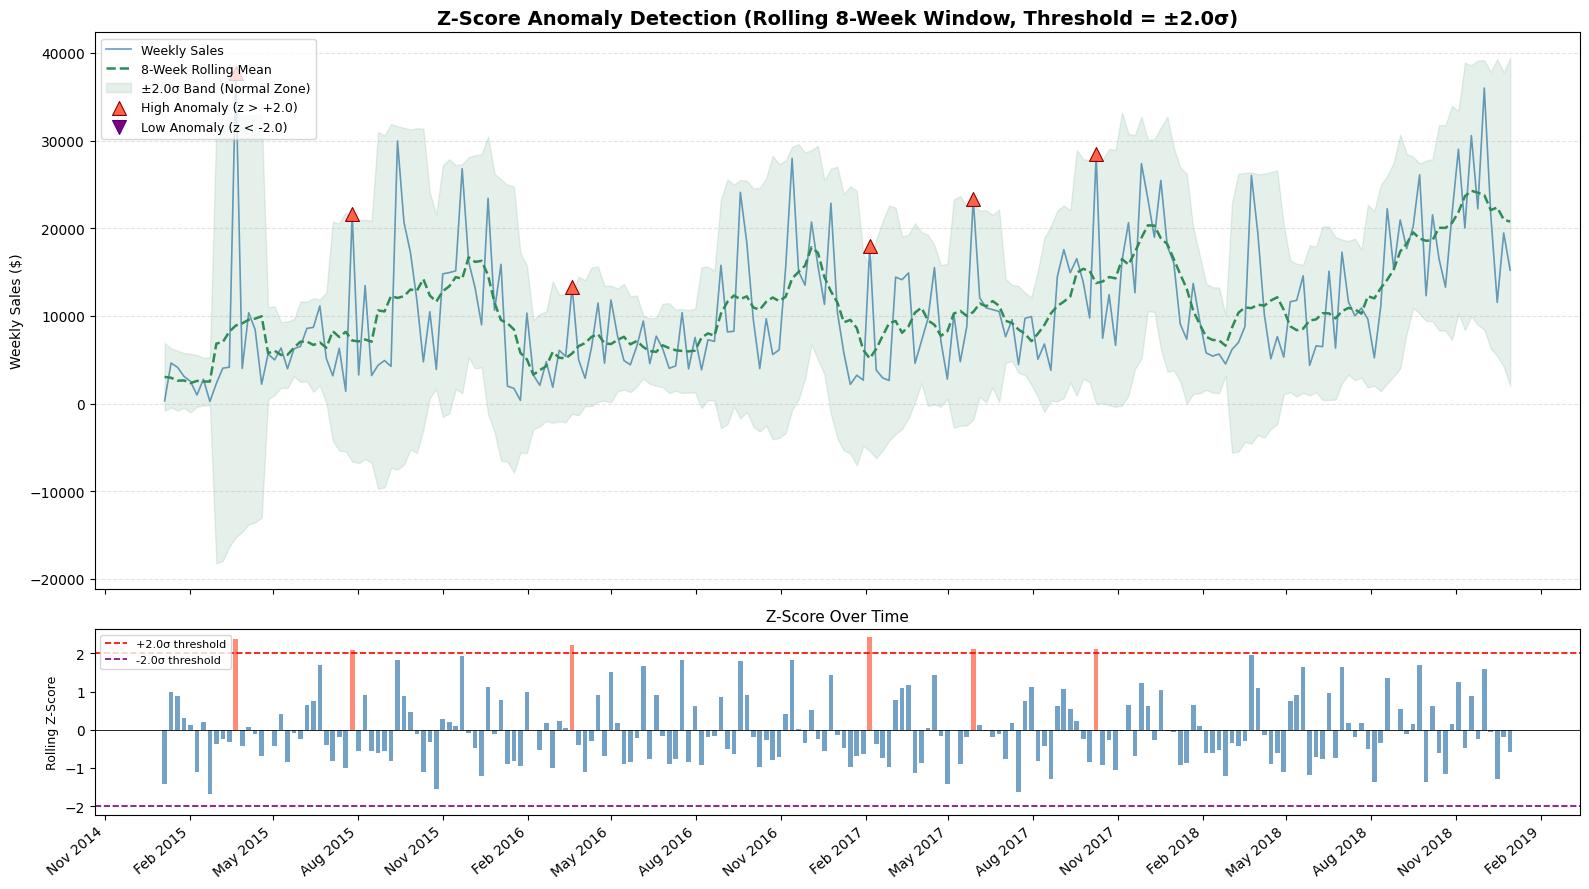

✅ Z-Score plot saved.
  METHOD COMPARISON — ISOLATION FOREST vs Z-SCORE

  Total weeks analysed      : 209
  Isolation Forest anomalies: 15
  Z-Score anomalies         : 6

   Flagged by BOTH methods : 1  ← High-confidence anomalies
   Only Isolation Forest   : 14
   Only Z-Score            : 5
   Flagged by either       : 20

High-confidence anomalies (flagged by BOTH):
  22 Mar 2015  —  Sales: $    37,704  |  Z-Score: +2.38


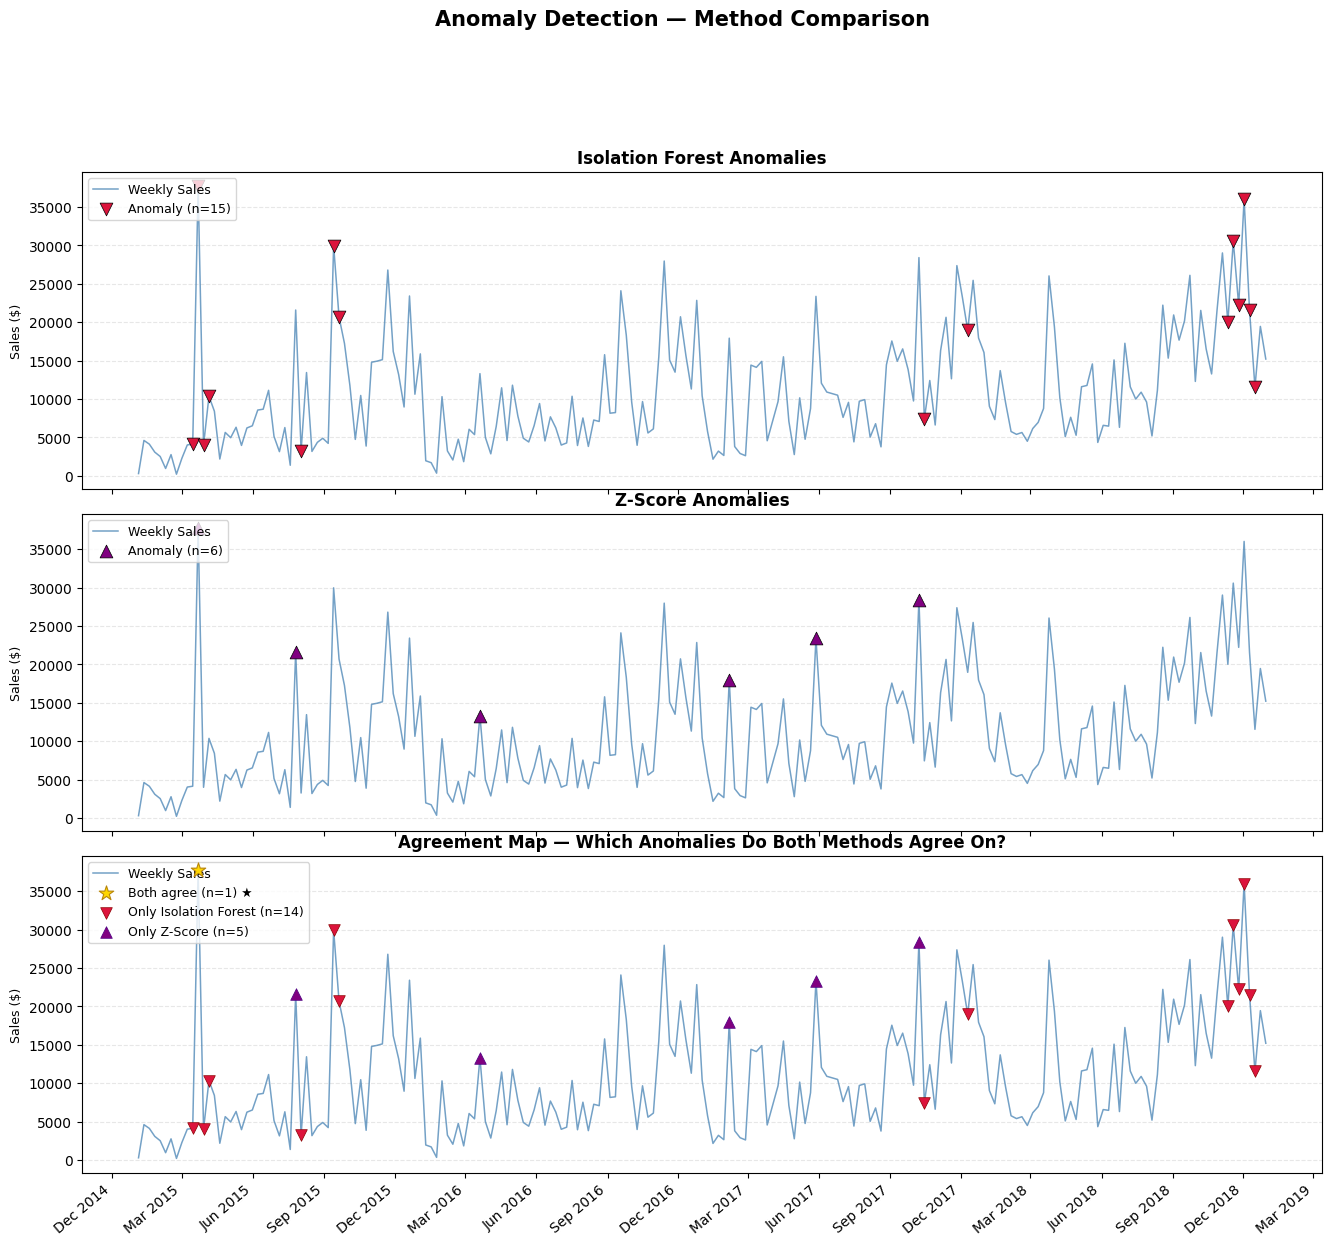

✅ Comparison plot saved.


In [15]:
#Task-4 Method 2

# METHOD 2 — Z-Score Based Detection

# Compute rolling Z-Score

ROLL_WINDOW    = 8    # 8-week rolling window for local statistics
ZSCORE_THRESH  = 2.0  # Flag if |z| > 2 standard deviations

roll_mean_z = weekly_ts.rolling(ROLL_WINDOW, center=True, min_periods=4).mean()
roll_std_z  = weekly_ts.rolling(ROLL_WINDOW, center=True, min_periods=4).std()

z_scores     = (weekly_ts - roll_mean_z) / roll_std_z
z_anomaly_mask = z_scores.abs() > ZSCORE_THRESH

z_anomalies  = weekly_ts[z_anomaly_mask]
z_normal     = weekly_ts[~z_anomaly_mask]

print(f"Z-Score method detected {len(z_anomalies)} anomalous weeks "
      f"({len(z_anomalies)/len(weekly_ts)*100:.1f}% of all weeks)")
print(f"\nThreshold used: ±{ZSCORE_THRESH} standard deviations "
      f"from {ROLL_WINDOW}-week rolling mean\n")
print("Flagged weeks:")
z_detail = pd.DataFrame({
    'Date'   : z_anomalies.index,
    'Sales'  : z_anomalies.values,
    'Z-Score': z_scores[z_anomaly_mask].values
}).sort_values('Z-Score', key=abs, ascending=False)
print(z_detail.to_string(index=False))
#Z-Score Plot

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Top: sales with Z-Score anomaly bands
ax1.plot(weekly_ts.index, weekly_ts.values,
         color='steelblue', linewidth=1.2, alpha=0.8,
         label='Weekly Sales', zorder=1)
ax1.plot(roll_mean_z.index, roll_mean_z.values,
         color='seagreen', linewidth=1.8, linestyle='--',
         label=f'{ROLL_WINDOW}-Week Rolling Mean', zorder=2)
ax1.fill_between(weekly_ts.index,
                 roll_mean_z - ZSCORE_THRESH * roll_std_z,
                 roll_mean_z + ZSCORE_THRESH * roll_std_z,
                 alpha=0.12, color='seagreen',
                 label=f'±{ZSCORE_THRESH}σ Band (Normal Zone)')

# High and low anomalies in different colors
high_mask = z_anomaly_mask & (z_scores > 0)
low_mask  = z_anomaly_mask & (z_scores < 0)

ax1.scatter(weekly_ts[high_mask].index, weekly_ts[high_mask].values,
            color='tomato', s=100, zorder=5, marker='^',
            edgecolors='darkred', linewidth=0.8,
            label=f'High Anomaly (z > +{ZSCORE_THRESH})')
ax1.scatter(weekly_ts[low_mask].index, weekly_ts[low_mask].values,
            color='purple', s=100, zorder=5, marker='v',
            edgecolors='indigo', linewidth=0.8,
            label=f'Low Anomaly (z < -{ZSCORE_THRESH})')

ax1.set_title(f'Z-Score Anomaly Detection (Rolling {ROLL_WINDOW}-Week Window, '
              f'Threshold = ±{ZSCORE_THRESH}σ)',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Weekly Sales ($)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.35)

# Bottom: Z-Score over time
ax2.bar(weekly_ts.index,
        z_scores.values,
        color=np.where(z_scores.abs() > ZSCORE_THRESH, 'tomato', 'steelblue'),
        width=5, alpha=0.75)
ax2.axhline(ZSCORE_THRESH,  color='red',    linewidth=1.2,
            linestyle='--', label=f'+{ZSCORE_THRESH}σ threshold')
ax2.axhline(-ZSCORE_THRESH, color='purple', linewidth=1.2,
            linestyle='--', label=f'-{ZSCORE_THRESH}σ threshold')
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_ylabel('Rolling Z-Score', fontsize=9)
ax2.set_title('Z-Score Over Time', fontsize=11)
ax2.legend(fontsize=8, loc='upper left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.savefig('task5_zscore.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Z-Score plot saved.")
# ============================================================
# METHOD COMPARISON — Do they agree?
# ============================================================

iso_dates = set(iso_anomalies.index.normalize())
z_dates   = set(z_anomalies.index.normalize())

both_flagged    = iso_dates & z_dates          # Agreement
only_iso        = iso_dates - z_dates          # Only Isolation Forest
only_z          = z_dates   - iso_dates        # Only Z-Score
either_flagged  = iso_dates | z_dates          # Union

print("=" * 65)
print("  METHOD COMPARISON — ISOLATION FOREST vs Z-SCORE")
print("=" * 65)
print(f"""
  Total weeks analysed      : {len(weekly_ts)}
  Isolation Forest anomalies: {len(iso_dates)}
  Z-Score anomalies         : {len(z_dates)}

   Flagged by BOTH methods : {len(both_flagged)}  ← High-confidence anomalies
   Only Isolation Forest   : {len(only_iso)}
   Only Z-Score            : {len(only_z)}
   Flagged by either       : {len(either_flagged)}
""")

if both_flagged:
    print("High-confidence anomalies (flagged by BOTH):")
    for d in sorted(both_flagged):
        print(f"  {d.strftime('%d %b %Y')}  —  "
              f"Sales: ${weekly_ts[d]:>10,.0f}  |  "
              f"Z-Score: {z_scores[d]:>+.2f}")
# ── Side-by-side visual comparison ───────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True,
                          gridspec_kw={'hspace': 0.08})

panel_cfg = [
    ('Isolation Forest Anomalies',  iso_anomalies.index, 'crimson',  'v', iso_dates),
    ('Z-Score Anomalies',           z_anomalies.index,   'purple',   '^', z_dates),
    ('Agreement Map',               None,                 None,       None, None),
]

for i, (title, anom_idx, color, marker, _) in enumerate(panel_cfg[:2]):
    ax = axes[i]
    ax.plot(weekly_ts.index, weekly_ts.values,
            color='steelblue', linewidth=1.1, alpha=0.75, label='Weekly Sales')
    ax.scatter(anom_idx, weekly_ts[anom_idx],
               color=color, s=85, zorder=5, marker=marker,
               edgecolors='black', linewidth=0.5,
               label=f'Anomaly (n={len(anom_idx)})')
    ax.set_ylabel('Sales ($)', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Agreement panel
ax3 = axes[2]
ax3.plot(weekly_ts.index, weekly_ts.values,
         color='steelblue', linewidth=1.1, alpha=0.75, label='Weekly Sales')

# Colour-code by agreement
both_idx  = weekly_ts.index[weekly_ts.index.normalize().isin(both_flagged)]
only_i    = weekly_ts.index[weekly_ts.index.normalize().isin(only_iso)]
only_z_   = weekly_ts.index[weekly_ts.index.normalize().isin(only_z)]

if len(both_idx):
    ax3.scatter(both_idx, weekly_ts[both_idx],
                color='gold', s=120, zorder=6, marker='*',
                edgecolors='darkgoldenrod', linewidth=0.8,
                label=f'Both agree (n={len(both_idx)}) ★')
if len(only_i):
    ax3.scatter(only_i, weekly_ts[only_i],
                color='crimson', s=70, zorder=5, marker='v',
                edgecolors='darkred', linewidth=0.5,
                label=f'Only Isolation Forest (n={len(only_i)})')
if len(only_z_):
    ax3.scatter(only_z_, weekly_ts[only_z_],
                color='purple', s=70, zorder=5, marker='^',
                edgecolors='indigo', linewidth=0.5,
                label=f'Only Z-Score (n={len(only_z_)})')

ax3.set_ylabel('Sales ($)', fontsize=9)
ax3.set_title('Agreement Map — Which Anomalies Do Both Methods Agree On?',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, loc='upper left')
ax3.grid(axis='y', linestyle='--', alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=40, ha='right')

plt.suptitle('Anomaly Detection — Method Comparison',
             fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('task5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison plot saved.")


# *Comparison :*

---


They don't always flag the same things, but that's actually a feature, not a bug. Z-score is great at catching massive, sudden spikes, while Isolation Forest sniffs out quieter, weird patterns that just look out of place in context. If both flag a week, it's a major red flag; if only one does, it's just a friendly nudge to go take a quick look.

Sub-category feature matrix:
              total_sales  avg_order_value  volatility  yoy_growth_pct
Sub-Category                                                          
Accessories     164186.70           217.18     2579.99          145.06
Appliances      104618.40           227.93     1821.62          165.24
Art              26705.41            34.02      330.49           49.65
Binders         200028.78           134.07     3848.22           65.78
Bookcases       113813.20           503.60     2220.41           49.85
Chairs          322822.73           531.83     4407.23           20.95
Copiers         146248.09          2215.88     5500.77          479.73
Envelopes        16128.05            65.03      228.22          -12.12
Fasteners         3001.96            14.03       48.74           30.47
Furnishings      89212.02            95.82     1360.02          106.82
Labels           12347.73            34.59      223.47           36.07
Machines        189238.63          1645.55     5

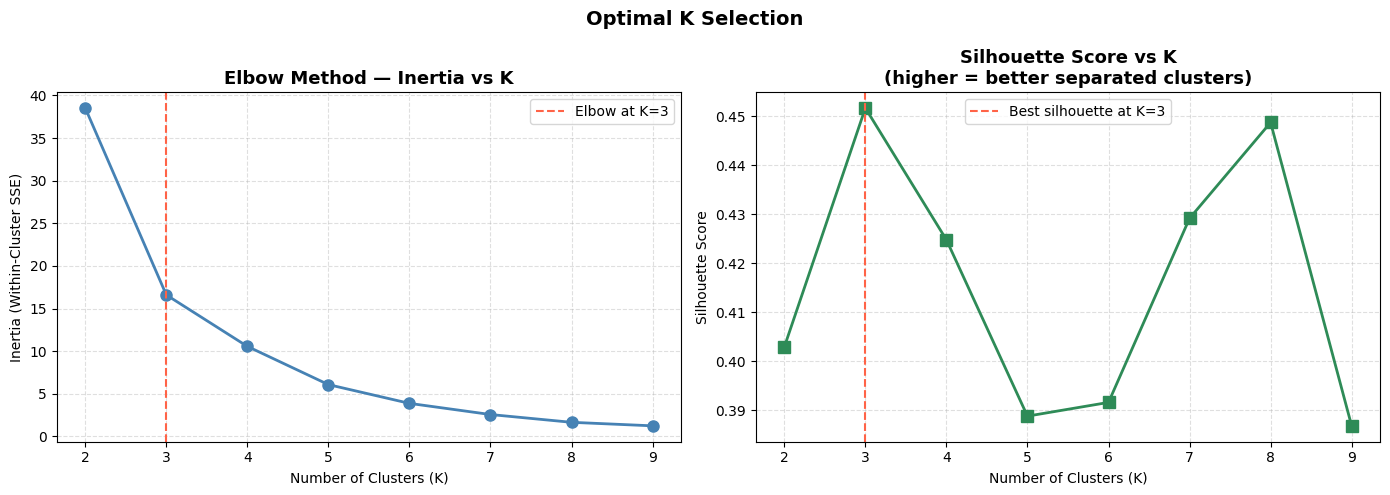


Elbow method suggests   K = 3
Silhouette score suggests K = 3
Selected K = 3
Sub-categories per cluster:
Cluster
0     1
1    10
2     6
Name: count, dtype: int64

Cluster centroids (scaled space):
   total_sales  avg_order_value  volatility  yoy_growth_pct
0        0.134            3.048       1.749           3.592
1       -0.687           -0.478      -0.709          -0.090
2        1.122            0.288       0.890          -0.448
Cluster Labels:

   Low Volume, Growing Demand
  Members: Copiers

   Mature, Stable Demand (Cluster 1)
  Members: Accessories, Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies

   Mature, Stable Demand (Cluster 2)
  Members: Binders, Chairs, Machines, Phones, Storage, Tables
PCA Feature Loadings:
                   PC1    PC2
total_sales      0.452 -0.600
avg_order_value  0.553  0.289
volatility       0.610 -0.219
yoy_growth_pct   0.343  0.713

Variance explained: PC1=61.8%  PC2=28.1%  Total=90.0%


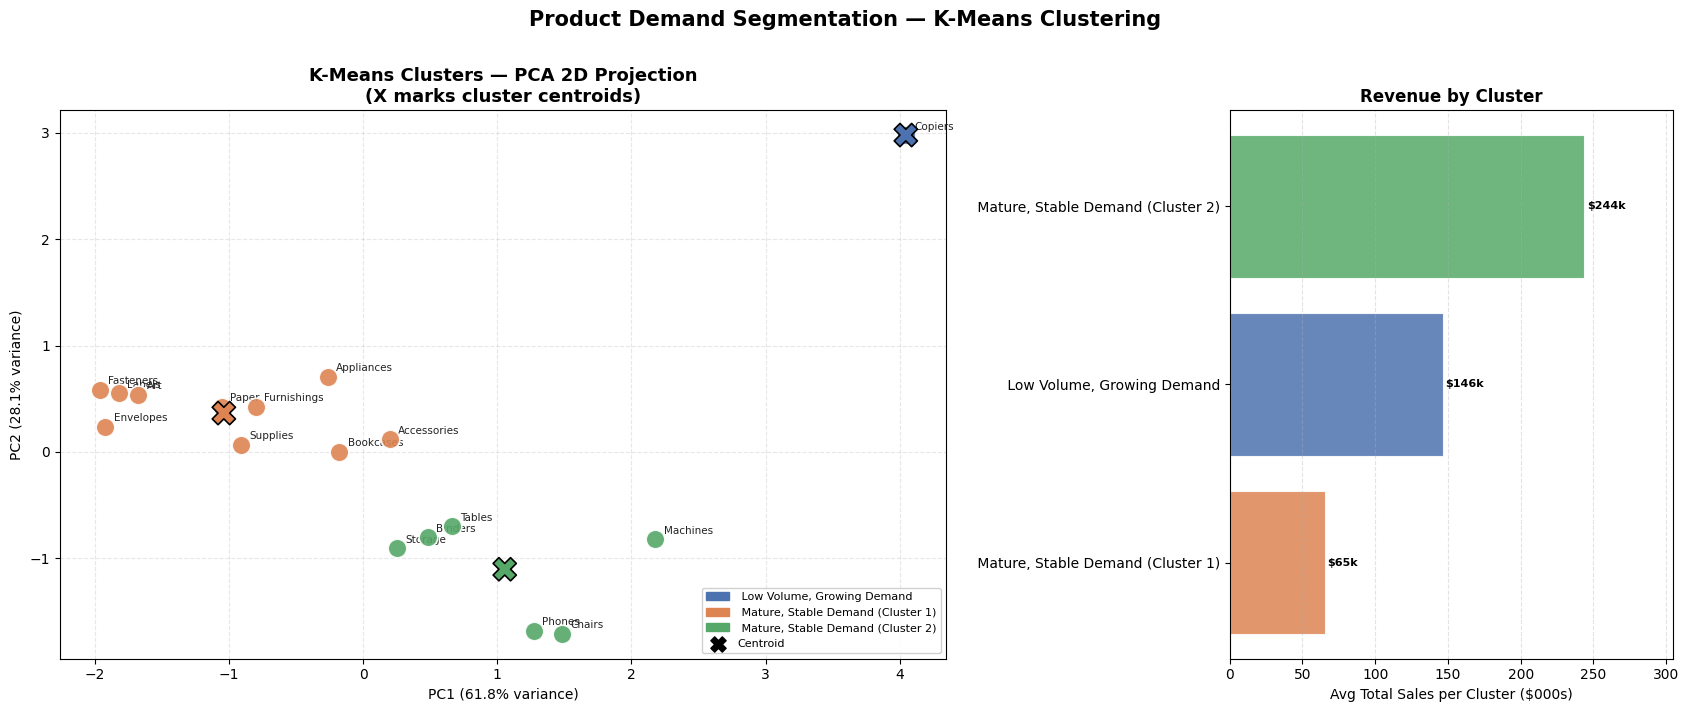

 Cluster scatter plot saved.


,Total Sales ($),Avg Order Value ($),Volatility ($),YoY Growth (%)
"Low Volume, Growing Demand","$146,248","$2,216","$5,501",+479.7%
"Mature, Stable Demand (Cluster 1)","$65,326",$150,"$1,186",+67.4%
"Mature, Stable Demand (Cluster 2)","$243,671",$599,"$3,993",+27.3%


  STOCKING STRATEGY BY CLUSTER

─────────────────────────────────────────────────────────────────
   Low Volume, Growing Demand
─────────────────────────────────────────────────────────────────
  Sub-categories : Copiers
  Avg Sales      : $   146,248
  Avg YoY Growth : +479.7%
  Avg Volatility : $     5,501
  Avg Order Value: $     2,216

  📦 Strategy    : Watch & Scale
  💡 Detail      : These are emerging products with upward momentum. Keep lean stock now (JIT — just-in-time ordering) but flag for quarterly review. If YoY growth continues for two more periods, move to a Continuous Replenishment strategy. Avoid over-investing in warehouse space before growth is confirmed.

─────────────────────────────────────────────────────────────────
   Mature, Stable Demand (Cluster 1)
─────────────────────────────────────────────────────────────────
  Sub-categories : Accessories, Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies
  Avg Sales      : $    65,32

In [19]:
#Task 6 — Product Demand Segmentation using Clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
from collections import Counter # Added to ensure unique cluster labels

# 1. Build sub-category feature matrix

# Total sales per sub-category
total_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .rename('total_sales')
)

# Average order value per sub-category
avg_order = (
    df.groupby('Sub-Category')['Sales']
    .mean()
    .rename('avg_order_value')
)

# Sales volatility — std of monthly sales per sub-category
monthly_subcat = (
    df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales']
    .sum()
    .reset_index()
)
volatility = (
    monthly_subcat.groupby('Sub-Category')['Sales']
    .std()
    .rename('volatility')
)

# Year-over-year growth rate
# Compare total sales in last year (2017) vs first year (2014)
yearly_subcat = (
    df.groupby(['Sub-Category', 'Year'])['Sales']
    .sum()
    .unstack(fill_value=0)
)
first_year = yearly_subcat.iloc[:, 0].replace(0, np.nan)
last_year  = yearly_subcat.iloc[:, -1]
yoy_growth = ((last_year - first_year) / first_year * 100).rename('yoy_growth_pct')

# Combine all features
feat_df = pd.concat([total_sales, avg_order, volatility, yoy_growth], axis=1).dropna()

print("Sub-category feature matrix:")
print(feat_df.round(2).to_string())
print(f"\nShape: {feat_df.shape}  ({feat_df.shape[0]} sub-categories × {feat_df.shape[1]} features)")
# 2. Scale features

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(feat_df)
X_scaled_df = pd.DataFrame(X_scaled, index=feat_df.index, columns=feat_df.columns)

print("Feature means after scaling (should all be ~0):")
print(X_scaled_df.mean().round(4))
print("\nFeature stds after scaling (should all be ~1):")
print(X_scaled_df.std().round(4))
# 3. Elbow Method — find optimal K

inertias    = []
sil_scores  = []
K_range     = range(2, min(10, len(feat_df)))

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
ax1.plot(list(K_range), inertias, marker='o', color='steelblue',
         linewidth=2, markersize=8)
ax1.set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-Cluster SSE)')
ax1.grid(linestyle='--', alpha=0.4)

# Annotate the elbow point (largest drop)
drops = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
elbow_k = list(K_range)[np.argmax(drops) + 1]
ax1.axvline(elbow_k, color='tomato', linestyle='--', linewidth=1.5,
            label=f'Elbow at K={elbow_k}')
ax1.legend()

# Silhouette scores
ax2.plot(list(K_range), sil_scores, marker='s', color='seagreen',
         linewidth=2, markersize=8)
ax2.set_title('Silhouette Score vs K\n(higher = better separated clusters)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(linestyle='--', alpha=0.4)

best_sil_k = list(K_range)[np.argmax(sil_scores)]
ax2.axvline(best_sil_k, color='tomato', linestyle='--', linewidth=1.5,
            label=f'Best silhouette at K={best_sil_k}')
ax2.legend()

plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task6_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# Choose K — prefer silhouette if it agrees with elbow, else elbow wins
OPTIMAL_K = best_sil_k
print(f"\nElbow method suggests   K = {elbow_k}")
print(f"Silhouette score suggests K = {best_sil_k}")
print(f"Selected K = {OPTIMAL_K}")
# 4. Fit final K-Means

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
feat_df['Cluster'] = km_final.fit_predict(X_scaled)

print("Sub-categories per cluster:")
print(feat_df.groupby('Cluster').size().rename('count'))
print("\nCluster centroids (scaled space):")
centroids_df = pd.DataFrame(
    km_final.cluster_centers_,
    columns=feat_df.columns[:-1]
).round(3)
print(centroids_df)
# 5. Auto-label clusters from centroid characteristics

# Map each cluster to a meaningful business label based on its
# centroid values in the original (unscaled) feature space.
cluster_means = feat_df.groupby('Cluster')[
    ['total_sales', 'avg_order_value', 'volatility', 'yoy_growth_pct']
].mean()

# Store initial, potentially non-unique labels
base_labels = {}
label_colors= {}
color_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52',
                 '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']

for c in range(OPTIMAL_K):
    row      = cluster_means.loc[c]
    high_vol = row['total_sales']   > cluster_means['total_sales'].median()
    growing  = row['yoy_growth_pct']> cluster_means['yoy_growth_pct'].median()
    volatile = row['volatility']    > cluster_means['volatility'].median()
    high_aov = row['avg_order_value']> cluster_means['avg_order_value'].median()

    if high_vol and growing and not volatile:
        label = ' High Volume, Stable Growth'
    elif high_vol and volatile:
        label = ' High Volume, High Volatility'
    elif not high_vol and growing:
        label = ' Low Volume, Growing Demand'
    elif not high_vol and not growing and volatile:
        label = ' Low Volume, High Volatility'
    elif high_aov and not high_vol:
        label = ' Niche, High-Value Orders'
    elif not growing and not volatile:
        label = ' Mature, Stable Demand'
    else:
        label = f' Cluster {c}'

    base_labels[c] = label
    label_colors[c] = color_palette[c % len(color_palette)]

# Now create truly unique labels for the `labels` dictionary
labels = {}
label_counts = Counter(base_labels.values())
for c in range(OPTIMAL_K):
    current_label = base_labels[c]
    if label_counts[current_label] > 1:
        # Append cluster ID to make it unique if there are duplicates
        labels[c] = f"{current_label} (Cluster {c})"
    else:
        labels[c] = current_label

feat_df['Label'] = feat_df['Cluster'].map(labels)

print("Cluster Labels:")
for c, lbl in labels.items(): # This now uses the unique labels
    members = feat_df[feat_df['Cluster'] == c].index.tolist()
    print(f"\n  {lbl}")
    print(f"  Members: {', '.join(members)}")
#6. PCA for 2D visualisation

pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_scaled)
var_exp   = pca.explained_variance_ratio_ * 100

feat_df['PCA1'] = X_pca[:, 0]
feat_df['PCA2'] = X_pca[:, 1]

# PCA loadings — which original features drive each component
loadings = pd.DataFrame(
    pca.components_.T,
    index=feat_df.columns[:4],
    columns=['PC1', 'PC2']
).round(3)
print("PCA Feature Loadings:")
print(loadings)
print(f"\nVariance explained: PC1={var_exp[0]:.1f}%  PC2={var_exp[1]:.1f}%  "
      f"Total={sum(var_exp):.1f}%")
# 7. Cluster scatter plot (PCA space)

fig, (ax_main, ax_bar) = plt.subplots(
    1, 2, figsize=(17, 7),
    gridspec_kw={'width_ratios': [2, 1]}
)

# Left: PCA scatter
for c in range(OPTIMAL_K):
    mask  = feat_df['Cluster'] == c
    color = label_colors[c]
    ax_main.scatter(
        feat_df.loc[mask, 'PCA1'],
        feat_df.loc[mask, 'PCA2'],
        color=color, s=180, zorder=4, alpha=0.9,
        edgecolors='white', linewidth=1.2
    )
    # Label each point with sub-category name
    for subcat in feat_df[mask].index:
        ax_main.annotate(
            subcat,
            xy=(feat_df.loc[subcat, 'PCA1'], feat_df.loc[subcat, 'PCA2']),
            xytext=(6, 4), textcoords='offset points',
            fontsize=7.5, color='#222222'
        )

# Plot centroids in PCA space
centroids_pca = pca.transform(km_final.cluster_centers_)
ax_main.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=280, color=[label_colors[c] for c in range(OPTIMAL_K)],
    edgecolors='black', linewidth=1.2, zorder=6, label='Centroid'
)

legend_patches = [
    mpatches.Patch(color=label_colors[c], label=labels[c])
    for c in range(OPTIMAL_K)
]
legend_patches.append(
    plt.scatter([], [], marker='X', s=120, color='black', label='Centroid')
)
ax_main.legend(handles=legend_patches, fontsize=8,
               loc='lower right', framealpha=0.9)
ax_main.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance)', fontsize=10)
ax_main.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance)', fontsize=10)
ax_main.set_title('K-Means Clusters — PCA 2D Projection\n'
                  '(X marks cluster centroids)',
                  fontsize=13, fontweight='bold')
ax_main.grid(linestyle='--', alpha=0.3)

# Right: bar chart of avg total sales per cluster
cluster_order = cluster_means['total_sales'].sort_values(ascending=True).index
bar_colors    = [label_colors[c] for c in cluster_order]
bars = ax_bar.barh(
    [labels[c] for c in cluster_order],
    cluster_means.loc[cluster_order, 'total_sales'] / 1000,
    color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, cluster_means.loc[cluster_order, 'total_sales'] / 1000):
    ax_bar.text(val + 2, bar.get_y() + bar.get_height()/2,
                f'${val:.0f}k', va='center', fontsize=8, fontweight='bold')

ax_bar.set_xlabel('Avg Total Sales per Cluster ($000s)', fontsize=10)
ax_bar.set_title('Revenue by Cluster', fontsize=12, fontweight='bold')
ax_bar.grid(axis='x', linestyle='--', alpha=0.35)
ax_bar.set_xlim(0, cluster_means['total_sales'].max() / 1000 * 1.25)

plt.suptitle('Product Demand Segmentation — K-Means Clustering',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task6_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Cluster scatter plot saved.")
# 8. Cluster profile table

from IPython.display import display

profile = cluster_means.copy()
profile.index = [labels[c] for c in profile.index]

profile.columns = ['Total Sales ($)', 'Avg Order Value ($)',
                   'Volatility ($)', 'YoY Growth (%)']

profile_styled = (
    profile.style
    .format({
        'Total Sales ($)'    : '${:,.0f}',
        'Avg Order Value ($)': '${:,.0f}',
        'Volatility ($)'     : '${:,.0f}',
        'YoY Growth (%)'     : '{:+.1f}%',
    })
    .background_gradient(subset=['Total Sales ($)'],    cmap='Blues')
    .background_gradient(subset=['YoY Growth (%)'],     cmap='RdYlGn')
    .background_gradient(subset=['Volatility ($)'],     cmap='Oranges')
    .background_gradient(subset=['Avg Order Value ($)'],cmap='Purples')
    .set_caption('Cluster Profile — Average Feature Values per Segment')
)
display(profile_styled)
# 9. Stocking strategy recommendation

print("=" * 65)
print("  STOCKING STRATEGY BY CLUSTER")
print("=" * 65)

strategies = {
    ' High Volume, Stable Growth': {
        'strategy': 'Continuous Replenishment',
        'detail'  : (
            "These sub-categories are your core revenue drivers with "
            "predictable demand. Use automated reorder points (ROP) "
            "tied to a fixed safety stock level (1–2 weeks of cover). "
            "Negotiate long-term supplier contracts for volume discounts. "
            "Invest in demand forecasting accuracy here — even a 1% "
            "improvement in forecast error directly protects revenue."
        )
    },
    ' High Volume, High Volatility': {
        'strategy': 'Buffer Stock + Flexible Procurement',
        'detail'  : (
            "High revenue but unpredictable swings make stockouts "
            "expensive and overstock risky. Maintain a higher safety "
            "stock buffer (3–4 weeks) and use flexible supplier contracts "
            "with short lead times. Monitor weekly rather than monthly. "
            "Consider promotions to smooth demand during low-sales periods."
        )
    },
    ' Low Volume, Growing Demand': {
        'strategy': 'Watch & Scale',
        'detail'  : (
            "These are emerging products with upward momentum. Keep "
            "lean stock now (JIT — just-in-time ordering) but flag for "
            "quarterly review. If YoY growth continues for two more "
            "periods, move to a Continuous Replenishment strategy. "
            "Avoid over-investing in warehouse space before growth is confirmed."
        )
    },
    ' Low Volume, High Volatility': {
        'strategy': 'On-Demand / Make-to-Order',
        'detail'  : (
            "Unpredictable and low-volume — the worst combination for "
            "inventory. Do not hold large standing stock. Instead, switch "
            "to order-triggered procurement: only purchase when a customer "
            "order is confirmed. Accept longer lead times in exchange for "
            "zero dead stock risk. Review quarterly for signs of growth or "
            "discontinuation candidates."
        )
    },
    ' Niche, High-Value Orders': {
        'strategy': 'Selective Stocking + Premium Supplier Terms',
        'detail'  : (
            "Low order frequency but each order is high value — losing "
            "even one sale to a stockout is costly. Hold minimal but "
            "non-zero safety stock (1–2 units or equivalent). Build a "
            "dedicated fast-response supplier relationship. Flag these "
            "products for VIP customer prioritisation in allocation."
        )
    },
    ' Mature, Stable Demand': {
        'strategy': 'Lean Replenishment + Rationalisation Review',
        'detail'  : (
            "Steady but flat — these products are not growing and not "
            "volatile. Use lean kanban-style replenishment with minimal "
            "safety stock. Conduct an annual SKU rationalisation review: "
            "if gross margin is below threshold, consider discontinuing "
            "in favour of growing sub-categories. Do not prioritise "
            "promotional spend on this cluster."
        )
    },
}

for c in range(OPTIMAL_K):
    lbl      = labels[c]
    members  = feat_df[feat_df['Cluster'] == c].index.tolist()
    stats    = cluster_means.loc[c]
    strategy = strategies.get(lbl, {})

    print(f"\n{'─'*65}")
    print(f"  {lbl}")
    print(f"{'─'*65}")
    print(f"  Sub-categories : {', '.join(members)}")
    print(f"  Avg Sales      : ${stats['total_sales']:>10,.0f}")
    print(f"  Avg YoY Growth : {stats['yoy_growth_pct']:>+.1f}%")
    print(f"  Avg Volatility : ${stats['volatility']:>10,.0f}")
    print(f"  Avg Order Value: ${stats['avg_order_value']:>10,.0f}")
    if strategy:
        print(f"\n  📦 Strategy    : {strategy['strategy']}")
        print(f"  💡 Detail      : {strategy['detail']}")